# exp 0 with the 1d ks pde data trained model arch, employing it to 2d data¶

In [3]:
import os, math, random, pickle, json
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

os.environ.setdefault("TORCHINDUCTOR_DISABLE_CUDAGRAPHS", "1")
os.environ.setdefault("TORCHINDUCTOR_CUDAGRAPHS", "0")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if DEVICE == "cuda":
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

print("DEVICE =", DEVICE)

# ------------------------------------------------------------
# paths
# ------------------------------------------------------------
DATA_FILE = Path("/scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/output_data.pkl")  # change if needed
RUN_DIR = Path("/scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data")
RUN_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# data facts from your file
# ------------------------------------------------------------
HIST_LEN = 3
MAX_K = 2   # fixed by your T=5 data

# ------------------------------------------------------------
# geometry / scalar conditioning
# if you know the true domain size, set it here
# if not, keep normalized box [0,1] x [0,1]
# ------------------------------------------------------------
Lx = 1.0
Ly = 1.0

# use dt from your data_config
DT_FROM_CONFIG = True

# ------------------------------------------------------------
# model / training
# ------------------------------------------------------------
FREQS = (1, 2, 4, 8)
DIVISORS = (1,)   # your stored data is already 64x64, keep this for now
INCLUDE_DXY_SCALARS = True

NORM_TYPE = "batch"
DROPOUT_F = 0.10
DROPOUT_S = 0.10
DU_CLIP_N = 5.0
DU_CORR_CLIP_N = 2.0

HIDDEN_F = 96
HIDDEN_S = 96
HIDDEN_D = 64

TRAIN_BATCH_SIZE = 64 if DEVICE == "cuda" else 16
EVAL_BATCH_SIZE = 64 if DEVICE == "cuda" else 16
NUM_WORKERS = 0

F_STEPS = 15000
S_STEPS = 12000

F_LR = 2e-4
S_LR = 2e-4
D_LR = 2e-4

F_WD = 1e-4
S_WD = 1e-4
D_WD = 1e-4

GRAD_CLIP_F = 1.0
GRAD_CLIP_S = 1.0

EVAL_EVERY = 500
LOG_EVERY = 100
SAVE_EVERY = 1000
MAX_VAL_BATCHES = 20

# scheduled sampling for F
TF_START = 0.90
TF_END = 0.00
TF_DECAY_STEPS = 8000

# losses
BETA_DU = 0.50
LAMBDA_GRAD = 0.05
LAMBDA_STATS = 0.001
LAMBDA_FFT = 0.02
LAMBDA_COH = 0.01

# S + D
INCLUDE_DU_BASE = True
K_ROLL_S = 2
N_CRITIC = 1
GP_LAMBDA = 10.0
LAMBDA_ADV = 0.02

# inference
TEST_TRAJ_ID = 0
LONG_FREE_RUN_STEPS = 50

print("RUN_DIR =", RUN_DIR)

DEVICE = cuda
RUN_DIR = /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data


In [4]:
def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

with open(DATA_FILE, "rb") as f:
    obj = pickle.load(f)

assert isinstance(obj, dict), "expected dict with keys ['data_config', 'data']"
assert "data" in obj, "missing key: data"
assert "data_config" in obj, "missing key: data_config"

data_config = obj["data_config"]
data = obj["data"]

data = to_numpy(data).astype(np.float32)
print("raw data shape:", data.shape)
print("data_config:", data_config)

# expected: [N, T, H, W]
assert data.ndim == 4, f"expected [N,T,H,W], got {data.shape}"
N, T, H, W = data.shape
assert T == 5, f"expected T=5 from your file, got T={T}"

# add channel dim -> [N, T, C, H, W]
data = data[:, :, None, :, :]
N, T, C, H, W = data.shape

if DT_FROM_CONFIG and "dt" in data_config:
    DT = float(data_config["dt"])
else:
    DT = 1.0

dx = Lx / W
dy = Ly / H

print("standardized data shape:", data.shape)
print(f"C={C}, H={H}, W={W}, DT={DT}, dx={dx}, dy={dy}")

# simple trajectory split
perm = np.random.RandomState(SEED).permutation(N)
n_train = int(0.80 * N)
n_val = int(0.10 * N)

idx_train = perm[:n_train]
idx_val   = perm[n_train:n_train+n_val]
idx_test  = perm[n_train+n_val:]

train_traj = data[idx_train]
val_traj   = data[idx_val]
test_traj  = data[idx_test]

print("train:", train_traj.shape)
print("val  :", val_traj.shape)
print("test :", test_traj.shape)

raw data shape: (20000, 5, 64, 64)
data_config: {'reynolds': 5000, 'trajectories': 20, 'increment': 5, 'rollout': 5, 'dt': 0.001, 'spinup': 10000, 'decorr_steps': 1500, 'gridsize': 512, 'downsample': 8, 'n_sims': 1000, 'save_path': 'Data_2D_Thermalizer/output_data.pkl', 'viscosity': 0.0002}
standardized data shape: (20000, 5, 1, 64, 64)
C=1, H=64, W=64, DT=0.001, dx=0.015625, dy=0.015625
train: (16000, 5, 1, 64, 64)
val  : (2000, 5, 1, 64, 64)
test : (2000, 5, 1, 64, 64)


In [5]:
def posenc_2d(H, W, Lx, Ly, freqs):
    xs = (np.arange(W, dtype=np.float32) + 0.5) * (Lx / W)
    ys = (np.arange(H, dtype=np.float32) + 0.5) * (Ly / H)

    chans = []

    for f in freqs:
        chans.append(np.sin(2.0 * np.pi * f * xs / max(Lx, 1e-8))[None, :].repeat(H, axis=0))
        chans.append(np.cos(2.0 * np.pi * f * xs / max(Lx, 1e-8))[None, :].repeat(H, axis=0))

    for f in freqs:
        chans.append(np.sin(2.0 * np.pi * f * ys / max(Ly, 1e-8))[:, None].repeat(W, axis=1))
        chans.append(np.cos(2.0 * np.pi * f * ys / max(Ly, 1e-8))[:, None].repeat(W, axis=1))

    return np.stack(chans, axis=0).astype(np.float32)

PE = posenc_2d(H, W, Lx, Ly, FREQS)
PE_CH = PE.shape[0]
print("PE shape:", PE.shape)

class Thermalizer5StepDataset(Dataset):
    def __init__(self, trajectories, pe, Lx, Ly, dt, dx, dy, include_dxy=True):
        super().__init__()
        self.X = trajectories.astype(np.float32, copy=False)  # [N,5,C,H,W]
        self.pe = pe.astype(np.float32, copy=False)
        self.Lx = float(Lx)
        self.Ly = float(Ly)
        self.dt = float(dt)
        self.dx = float(dx)
        self.dy = float(dy)
        self.include_dxy = bool(include_dxy)

        assert self.X.shape[1] == 5, self.X.shape

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        traj = self.X[idx]    # [5,C,H,W]

        u_tm2 = traj[0]
        u_tm1 = traj[1]
        u_t   = traj[2]
        fut   = traj[3:5]     # [2,C,H,W]

        profiles = np.concatenate([u_tm2, u_tm1, u_t, self.pe], axis=0).astype(np.float32)

        scalars = [self.Lx, self.Ly, self.dt]
        if self.include_dxy:
            scalars.extend([self.dx, self.dy])

        return {
            "profiles_raw": profiles,
            "future_raw": fut,
            "scalars": np.array(scalars, dtype=np.float32),
        }

def make_loader(trajs, shuffle, batch_size):
    ds = Thermalizer5StepDataset(
        trajectories=trajs,
        pe=PE,
        Lx=Lx,
        Ly=Ly,
        dt=DT,
        dx=dx,
        dy=dy,
        include_dxy=INCLUDE_DXY_SCALARS,
    )
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
        drop_last=shuffle,
    )
    return dl

train_loader = make_loader(train_traj, True, TRAIN_BATCH_SIZE)
val_loader   = make_loader(val_traj, False, EVAL_BATCH_SIZE)
test_loader  = make_loader(test_traj, False, EVAL_BATCH_SIZE)

print("train batches:", len(train_loader))
print("val batches  :", len(val_loader))
print("test batches :", len(test_loader))

PE shape: (16, 64, 64)
train batches: 250
val batches  : 32
test batches : 32


In [10]:
def compute_norms(train_traj):
    # train_traj: [N,T,C,H,W]

    # mean/std over N,T,H,W -> keep only channel dim
    u_mean_np = train_traj.mean(axis=(0, 1, 3, 4), keepdims=False).astype(np.float32)   # [C]
    u_std_np  = (train_traj.std(axis=(0, 1, 3, 4), keepdims=False) + 1e-6).astype(np.float32)  # [C]

    du = train_traj[:, 1:] - train_traj[:, :-1]
    du_mean_np = du.mean(axis=(0, 1, 3, 4), keepdims=False).astype(np.float32)   # [C]
    du_std_np  = (du.std(axis=(0, 1, 3, 4), keepdims=False) + 1e-6).astype(np.float32)  # [C]

    # reshape to [1,C,1,1] so they broadcast correctly with [B,C,H,W]
    u_mean = torch.from_numpy(u_mean_np.reshape(1, -1, 1, 1)).to(DEVICE)
    u_std  = torch.from_numpy(u_std_np.reshape(1, -1, 1, 1)).to(DEVICE)
    du_mean = torch.from_numpy(du_mean_np.reshape(1, -1, 1, 1)).to(DEVICE)
    du_std  = torch.from_numpy(du_std_np.reshape(1, -1, 1, 1)).to(DEVICE)

    return u_mean, u_std, du_mean, du_std

u_mean, u_std, du_mean, du_std = compute_norms(train_traj)

print("u_mean shape :", tuple(u_mean.shape))
print("u_std shape  :", tuple(u_std.shape))
print("du_mean shape:", tuple(du_mean.shape))
print("du_std shape :", tuple(du_std.shape))

print("u_std range :", float(u_std.min()), float(u_std.max()))
print("du_std range:", float(du_std.min()), float(du_std.max()))

Sdim = 3 + (2 if INCLUDE_DXY_SCALARS else 0)
Cin_F = 3 * C + PE_CH
Cin_S = 3 * C + (C if INCLUDE_DU_BASE else 0) + PE_CH
Cin_D = 3 * C + PE_CH + C

print("Cin_F =", Cin_F)
print("Cin_S =", Cin_S)
print("Cin_D =", Cin_D)
print("Sdim  =", Sdim)

u_mean shape : (1, 1, 1, 1)
u_std shape  : (1, 1, 1, 1)
du_mean shape: (1, 1, 1, 1)
du_std shape : (1, 1, 1, 1)
u_std range : 4.72756290435791 4.72756290435791
du_std range: 0.12508833408355713 0.12508833408355713
Cin_F = 19
Cin_S = 20
Cin_D = 20
Sdim  = 5


In [11]:
class BatchOrLayerNorm2d(nn.Module):
    def __init__(self, num_features, norm_type="batch"):
        super().__init__()
        if norm_type == "batch":
            self.norm = nn.BatchNorm2d(num_features)
        elif norm_type == "layer":
            self.norm = nn.GroupNorm(1, num_features)
        else:
            raise ValueError("norm_type must be 'batch' or 'layer'")

    def forward(self, x):
        return self.norm(x)

class ResidualDilated2D(nn.Module):
    def __init__(self, ch, d, norm_type="batch", dropout_p=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, kernel_size=3, padding=d, dilation=d, padding_mode="circular", bias=False)
        self.norm1 = BatchOrLayerNorm2d(ch, norm_type)
        self.act1 = nn.SiLU(inplace=True)
        self.drop1 = nn.Dropout2d(dropout_p)

        self.conv2 = nn.Conv2d(ch, ch, kernel_size=3, padding=1, padding_mode="circular", bias=False)
        self.norm2 = BatchOrLayerNorm2d(ch, norm_type)
        self.act2 = nn.SiLU(inplace=True)
        self.drop2 = nn.Dropout2d(dropout_p)

    def forward(self, x):
        y = self.drop1(self.act1(self.norm1(self.conv1(x))))
        y = self.drop2(self.norm2(self.conv2(y)))
        return self.act2(x + y)

class Forecaster2D(nn.Module):
    def __init__(self, cin, scalar_dim, cout, hidden=96, norm_type="batch", dropout_p=0.1, du_clip_n=5.0):
        super().__init__()
        self.du_clip_n = float(du_clip_n)

        self.stem = nn.Sequential(
            nn.Conv2d(cin, hidden, kernel_size=3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
        )

        self.b1 = ResidualDilated2D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated2D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated2D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated2D(hidden, 8, norm_type, dropout_p)
        self.b5 = ResidualDilated2D(hidden, 16, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(128, 32),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv2d(hidden + 32, hidden, kernel_size=1),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(hidden, cout, kernel_size=1),
        )

    def forward(self, x, scalars):
        h = self.stem(x)
        h = self.b5(self.b4(self.b3(self.b2(self.b1(h)))))

        B, _, Hh, Wh = h.shape
        s = self.scalar_proj(scalars)[:, :, None, None].expand(B, 32, Hh, Wh)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)

        c = self.du_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out

class Stabilizer2D(nn.Module):
    def __init__(self, cin, scalar_dim, cout, hidden=96, norm_type="batch", dropout_p=0.1, du_corr_clip_n=2.0):
        super().__init__()
        self.du_corr_clip_n = float(du_corr_clip_n)

        self.stem = nn.Sequential(
            nn.Conv2d(cin, hidden, kernel_size=3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
        )

        self.b1 = ResidualDilated2D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated2D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated2D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated2D(hidden, 8, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 64),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(64, 16),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv2d(hidden + 16, hidden, kernel_size=1),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(hidden, cout, kernel_size=1),
        )

    def forward(self, x, scalars):
        h = self.stem(x)
        h = self.b4(self.b3(self.b2(self.b1(h))))

        B, _, Hh, Wh = h.shape
        s = self.scalar_proj(scalars)[:, :, None, None].expand(B, 16, Hh, Wh)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)

        c = self.du_corr_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out

class PatchCritic2D(nn.Module):
    def __init__(self, cin, scalar_dim, hidden=64):
        super().__init__()

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 32),
            nn.SiLU(inplace=True),
            nn.Linear(32, 8),
            nn.SiLU(inplace=True),
        )

        def block(c_in, c_out, k=5, s=2, p=2):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, kernel_size=k, stride=s, padding=p, padding_mode="circular", bias=True),
                nn.LeakyReLU(0.2, inplace=True),
            )

        self.net = nn.Sequential(
            block(cin + 8, hidden, 5, 2, 2),
            block(hidden, hidden * 2, 5, 2, 2),
            block(hidden * 2, hidden * 4, 5, 2, 2),
            nn.Conv2d(hidden * 4, 1, kernel_size=3, padding=1, padding_mode="circular", bias=True),
        )

    def forward(self, x, scalars):
        B, _, Hh, Wh = x.shape
        s = self.scalar_proj(scalars)[:, :, None, None].expand(B, 8, Hh, Wh)
        h = torch.cat([x, s], dim=1)
        return self.net(h)

model_F = Forecaster2D(
    cin=Cin_F,
    scalar_dim=Sdim,
    cout=C,
    hidden=HIDDEN_F,
    norm_type=NORM_TYPE,
    dropout_p=DROPOUT_F,
    du_clip_n=DU_CLIP_N,
).to(DEVICE)

model_S = Stabilizer2D(
    cin=Cin_S,
    scalar_dim=Sdim,
    cout=C,
    hidden=HIDDEN_S,
    norm_type=NORM_TYPE,
    dropout_p=DROPOUT_S,
    du_corr_clip_n=DU_CORR_CLIP_N,
).to(DEVICE)

model_D = PatchCritic2D(
    cin=Cin_D,
    scalar_dim=Sdim,
    hidden=HIDDEN_D,
).to(DEVICE)

print("F params:", sum(p.numel() for p in model_F.parameters()))
print("S params:", sum(p.numel() for p in model_S.parameters()))
print("D params:", sum(p.numel() for p in model_D.parameters()))

F params: 865537
S params: 695121
D params: 1072009


In [12]:
def get_tf_prob(step):
    a = min(max(step / max(1, TF_DECAY_STEPS), 0.0), 1.0)
    return (1.0 - a) * TF_START + a * TF_END

def circular_grad_2d(u):
    gx = torch.roll(u, shifts=-1, dims=-1) - u
    gy = torch.roll(u, shifts=-1, dims=-2) - u
    return gx, gy

def fft_mag_2d(u):
    return torch.abs(torch.fft.rfftn(u, dim=(-2, -1), norm="ortho"))

def fft_coherence_loss_2d(u_pred, u_true, eps=1e-8):
    Zp = torch.fft.rfftn(u_pred, dim=(-2, -1), norm="ortho")
    Zt = torch.fft.rfftn(u_true, dim=(-2, -1), norm="ortho")
    num = (Zp * torch.conj(Zt)).real
    den = (torch.abs(Zp) * torch.abs(Zt)).clamp_min(eps)
    coh = 1.0 - (num / den)
    return coh.mean()

def weighted_mse(pred, target):
    return (pred - target).pow(2).mean()

def step_loss_terms(u_pred, u_true, u_in, du_pred):
    loss_u = weighted_mse(u_pred, u_true)

    du_true = u_true - u_in
    loss_du = weighted_mse(du_pred, du_true)

    if LAMBDA_GRAD > 0:
        gxp, gyp = circular_grad_2d(u_pred)
        gxt, gyt = circular_grad_2d(u_true)
        loss_grad = weighted_mse(gxp, gxt) + weighted_mse(gyp, gyt)
    else:
        loss_grad = torch.zeros((), device=u_pred.device)

    if LAMBDA_STATS > 0:
        mu_p = u_pred.mean(dim=(-2, -1))
        mu_t = u_true.mean(dim=(-2, -1))
        sig_p = u_pred.std(dim=(-2, -1))
        sig_t = u_true.std(dim=(-2, -1))
        loss_stats = (mu_p - mu_t).pow(2).mean() + (sig_p - sig_t).pow(2).mean()
    else:
        loss_stats = torch.zeros((), device=u_pred.device)

    if LAMBDA_FFT > 0:
        mp = fft_mag_2d(u_pred)
        mt = fft_mag_2d(u_true)
        loss_fft = (mp - mt).pow(2).mean()
    else:
        loss_fft = torch.zeros((), device=u_pred.device)

    if LAMBDA_COH > 0:
        loss_coh = fft_coherence_loss_2d(u_pred, u_true)
    else:
        loss_coh = torch.zeros((), device=u_pred.device)

    return loss_u, loss_du, loss_grad, loss_stats, loss_fft, loss_coh

def mix_losses(loss_u, loss_du, loss_grad, loss_stats, loss_fft, loss_coh):
    out = (1.0 - BETA_DU) * loss_u + BETA_DU * loss_du
    out = out + LAMBDA_GRAD * loss_grad + LAMBDA_STATS * loss_stats + LAMBDA_FFT * loss_fft + LAMBDA_COH * loss_coh
    return out

def forecaster_step(u_tm2, u_tm1, u_t, pe, scalars):
    u_tm2_n = (u_tm2 - u_mean) / u_std
    u_tm1_n = (u_tm1 - u_mean) / u_std
    u_t_n   = (u_t   - u_mean) / u_std

    xF = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
    du_n = model_F(xF, scalars)
    du = du_n * du_std + du_mean
    u_next = u_t + du

    return u_next, du, du_n, (u_tm2_n, u_tm1_n, u_t_n)

def build_S_input(u_tm2_n, u_tm1_n, u_t_n, pe, du_base_n=None):
    if du_base_n is None:
        return torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
    return torch.cat([u_tm2_n, u_tm1_n, u_t_n, du_base_n, pe], dim=1)

def critic_gp(x_real, x_fake, scalars):
    B = x_real.shape[0]
    alpha = torch.rand(B, 1, 1, 1, device=x_real.device)
    x_hat = alpha * x_real + (1.0 - alpha) * x_fake
    x_hat.requires_grad_(True)

    d_hat = model_D(x_hat, scalars)
    grad = torch.autograd.grad(
        outputs=d_hat.sum(),
        inputs=x_hat,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    grad = grad.reshape(B, -1)
    gp = ((grad.norm(2, dim=1) - 1.0) ** 2).mean()
    return GP_LAMBDA * gp

@torch.no_grad()
def rmse_t(pred, target):
    return torch.sqrt(torch.mean((pred - target) ** 2)).item()

@torch.no_grad()
def rollout_eval_metrics(loader, use_stabilizer=False, max_batches=20):
    model_F.eval()
    model_S.eval()

    rmse_1 = []
    rmse_2 = []
    mse_all = []

    nb = 0
    for batch in loader:
        profiles_raw = batch["profiles_raw"].to(DEVICE)
        future_raw   = batch["future_raw"].to(DEVICE)
        scalars      = batch["scalars"].to(DEVICE)

        u_tm2 = profiles_raw[:, 0:C]
        u_tm1 = profiles_raw[:, C:2*C]
        u_t   = profiles_raw[:, 2*C:3*C]
        pe    = profiles_raw[:, 3*C:]

        # step 1
        u_next1_F, du1_base, du1_base_n, (u_tm2_n, u_tm1_n, u_t_n) = forecaster_step(u_tm2, u_tm1, u_t, pe, scalars)

        if use_stabilizer:
            xS1 = build_S_input(u_tm2_n, u_tm1_n, u_t_n, pe, du1_base_n if INCLUDE_DU_BASE else None)
            du1_corr_n = model_S(xS1, scalars)
            du1_corr = du1_corr_n * du_std
            u_next1 = u_t + du1_base + du1_corr
            du1_tot = du1_base + du1_corr
        else:
            u_next1 = u_next1_F
            du1_tot = du1_base

        y1 = future_raw[:, 0]
        rmse_1.append(rmse_t(u_next1, y1))
        mse_all.append(weighted_mse(u_next1, y1).item())

        # step 2
        u_tm2_b = u_tm1
        u_tm1_b = u_t
        u_t_b   = u_next1

        u_next2_F, du2_base, du2_base_n, (u_tm2_n2, u_tm1_n2, u_t_n2) = forecaster_step(u_tm2_b, u_tm1_b, u_t_b, pe, scalars)

        if use_stabilizer:
            xS2 = build_S_input(u_tm2_n2, u_tm1_n2, u_t_n2, pe, du2_base_n if INCLUDE_DU_BASE else None)
            du2_corr_n = model_S(xS2, scalars)
            du2_corr = du2_corr_n * du_std
            u_next2 = u_t_b + du2_base + du2_corr
            du2_tot = du2_base + du2_corr
        else:
            u_next2 = u_next2_F
            du2_tot = du2_base

        y2 = future_raw[:, 1]
        rmse_2.append(rmse_t(u_next2, y2))
        mse_all.append(weighted_mse(u_next2, y2).item())

        nb += 1
        if nb >= max_batches:
            break

    return {
        "rmse_step1": float(np.mean(rmse_1)),
        "rmse_step2": float(np.mean(rmse_2)),
        "mse_mean": float(np.mean(mse_all)),
    }

use_amp = (DEVICE == "cuda")
if use_amp:
    try:
        scaler_F = torch.amp.GradScaler("cuda", enabled=True)
        scaler_S = torch.amp.GradScaler("cuda", enabled=True)
        autocast_ctx = lambda: torch.amp.autocast("cuda", dtype=torch.float16, enabled=True)
    except Exception:
        scaler_F = torch.cuda.amp.GradScaler(enabled=True)
        scaler_S = torch.cuda.amp.GradScaler(enabled=True)
        autocast_ctx = lambda: torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)
else:
    scaler_F = None
    scaler_S = None
    autocast_ctx = nullcontext

opt_F = torch.optim.AdamW(model_F.parameters(), lr=F_LR, weight_decay=F_WD)
opt_S = torch.optim.AdamW(model_S.parameters(), lr=S_LR, betas=(0.0, 0.9), weight_decay=S_WD)
opt_D = torch.optim.AdamW(model_D.parameters(), lr=D_LR, betas=(0.0, 0.9), weight_decay=D_WD)

In [13]:
F_best_path = RUN_DIR / "F_best.pt"
F_last_path = RUN_DIR / "F_last.pt"

history_F = []
best_val_F = float("inf")

def save_F(path, step, best_val):
    torch.save({
        "F": model_F.state_dict(),
        "opt_F": opt_F.state_dict(),
        "step": step,
        "best_val": best_val,
        "config": {
            "Cin_F": Cin_F,
            "C": C,
            "Sdim": Sdim,
            "freqs": FREQS,
            "Lx": Lx,
            "Ly": Ly,
            "DT": DT,
            "du_clip_n": DU_CLIP_N,
            "hidden_f": HIDDEN_F,
            "norm_type": NORM_TYPE,
        },
    }, path)

pbar = tqdm(range(1, F_STEPS + 1))
for step in pbar:
    model_F.train()

    batch = next(iter(train_loader))
    profiles_raw = batch["profiles_raw"].to(DEVICE)
    future_raw   = batch["future_raw"].to(DEVICE)
    scalars      = batch["scalars"].to(DEVICE)

    u_tm2 = profiles_raw[:, 0:C]
    u_tm1 = profiles_raw[:, C:2*C]
    u_t   = profiles_raw[:, 2*C:3*C]
    pe    = profiles_raw[:, 3*C:]

    tf_prob = get_tf_prob(step)

    opt_F.zero_grad(set_to_none=True)

    with autocast_ctx():
        # step 1
        u_next1, du1, du1_n, _ = forecaster_step(u_tm2, u_tm1, u_t, pe, scalars)
        y1 = future_raw[:, 0]
        l1 = mix_losses(*step_loss_terms(u_next1, y1, u_t, du1))

        # step 2 with scheduled sampling
        u_t2 = tf_prob * y1 + (1.0 - tf_prob) * u_next1
        u_next2, du2, du2_n, _ = forecaster_step(u_tm1, u_t, u_t2, pe, scalars)
        y2 = future_raw[:, 1]
        l2 = mix_losses(*step_loss_terms(u_next2, y2, u_t2, du2))

        loss_F = 0.5 * (l1 + l2)

    if scaler_F is not None:
        scaler_F.scale(loss_F).backward()
        scaler_F.unscale_(opt_F)
        nn.utils.clip_grad_norm_(model_F.parameters(), GRAD_CLIP_F)
        scaler_F.step(opt_F)
        scaler_F.update()
    else:
        loss_F.backward()
        nn.utils.clip_grad_norm_(model_F.parameters(), GRAD_CLIP_F)
        opt_F.step()

    pbar.set_description(f"F step={step} loss={loss_F.item():.4e}")

    if step % LOG_EVERY == 0:
        print(f"[F] step={step} loss={loss_F.item():.4e} tf_prob={tf_prob:.3f}")

    if step % EVAL_EVERY == 0 or step == 1:
        val_metrics = rollout_eval_metrics(val_loader, use_stabilizer=False, max_batches=MAX_VAL_BATCHES)
        msg = {"step": step, "train_loss": float(loss_F.item()), **val_metrics}
        history_F.append(msg)
        print("[F][val]", msg)

        score = val_metrics["mse_mean"]
        if score < best_val_F:
            best_val_F = score
            save_F(F_best_path, step, best_val_F)
            print("[F] saved best ->", F_best_path)

    if step % SAVE_EVERY == 0:
        save_F(F_last_path, step, best_val_F)

save_F(F_last_path, F_STEPS, best_val_F)
print("[F] training finished")

F step=2 loss=2.3100e-02:   0%|          | 2/15000 [00:09<15:54:42,  3.82s/it]

[F][val] {'step': 1, 'train_loss': 0.021762069314718246, 'rmse_step1': 0.12635263241827488, 'rmse_step2': 0.25084193870425225, 'mse_mean': 0.03946789016481489}
[F] saved best -> /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data/F_best.pt


F step=100 loss=4.2533e-03:   1%|          | 100/15000 [00:24<1:46:10,  2.34it/s]

[F] step=100 loss=4.2533e-03 tf_prob=0.889


F step=201 loss=2.9968e-03:   1%|▏         | 201/15000 [00:37<30:24,  8.11it/s]  

...

[F] step=14900 loss=6.2830e-04 tf_prob=0.000


F step=15000 loss=8.1222e-04: 100%|█████████▉| 14999/15000 [33:42<00:00,  8.95it/s]

[F] step=15000 loss=8.1222e-04 tf_prob=0.000


F step=15000 loss=8.1222e-04: 100%|██████████| 15000/15000 [33:43<00:00,  7.41it/s]

[F][val] {'step': 15000, 'train_loss': 0.00081222242442891, 'rmse_step1': 0.018390524480491877, 'rmse_step2': 0.03898712396621704, 'mse_mean': 0.0009342546647530981}
[F] training finished


In [14]:
if F_best_path.exists():
    ckpt = torch.load(F_best_path, map_location=DEVICE)
    model_F.load_state_dict(ckpt["F"], strict=True)
    print("[F] loaded best checkpoint")

for p in model_F.parameters():
    p.requires_grad_(False)
model_F.eval()

S_best_path = RUN_DIR / "S_best.pt"
S_last_path = RUN_DIR / "S_last.pt"

history_S = []
best_val_S = float("inf")

def save_S(path, step, best_val):
    torch.save({
        "S": model_S.state_dict(),
        "D": model_D.state_dict(),
        "opt_S": opt_S.state_dict(),
        "opt_D": opt_D.state_dict(),
        "step": step,
        "best_val": best_val,
        "config": {
            "Cin_S": Cin_S,
            "Cin_D": Cin_D,
            "include_du_base": INCLUDE_DU_BASE,
            "du_corr_clip_n": DU_CORR_CLIP_N,
            "hidden_s": HIDDEN_S,
            "hidden_d": HIDDEN_D,
        },
    }, path)

pbar = tqdm(range(1, S_STEPS + 1))
for step in pbar:
    model_S.train()
    model_D.train()

    batch = next(iter(train_loader))
    profiles_raw = batch["profiles_raw"].to(DEVICE)
    future_raw   = batch["future_raw"].to(DEVICE)
    scalars      = batch["scalars"].to(DEVICE)

    u_tm2 = profiles_raw[:, 0:C]
    u_tm1 = profiles_raw[:, C:2*C]
    u_t   = profiles_raw[:, 2*C:3*C]
    pe    = profiles_raw[:, 3*C:]

    # forward pass through two supervised rollout steps
    with torch.no_grad():
        u_next1_F, du1_base, du1_base_n, (u_tm2_n, u_tm1_n, u_t_n) = forecaster_step(u_tm2, u_tm1, u_t, pe, scalars)

    xS1 = build_S_input(u_tm2_n, u_tm1_n, u_t_n, pe, du1_base_n if INCLUDE_DU_BASE else None)
    du1_corr_n = model_S(xS1, scalars)
    du1_corr = du1_corr_n * du_std
    du1_tot = du1_base + du1_corr
    u_next1 = u_t + du1_tot
    y1 = future_raw[:, 0]

    # second step uses predicted history
    with torch.no_grad():
        u_next2_F, du2_base, du2_base_n, (u_tm2_n2, u_tm1_n2, u_t_n2) = forecaster_step(u_tm1, u_t, u_next1.detach(), pe, scalars)

    xS2 = build_S_input(u_tm2_n2, u_tm1_n2, u_t_n2, pe, du2_base_n if INCLUDE_DU_BASE else None)
    du2_corr_n = model_S(xS2, scalars)
    du2_corr = du2_corr_n * du_std
    du2_tot = du2_base + du2_corr
    u_next2 = u_next1.detach() + du2_tot
    y2 = future_raw[:, 1]

    sup_loss = 0.5 * (
        mix_losses(*step_loss_terms(u_next1, y1, u_t, du1_tot)) +
        mix_losses(*step_loss_terms(u_next2, y2, u_next1.detach(), du2_tot))
    )

    # choose one step for adversarial critic
    use_first = bool(random.getrandbits(1))
    if use_first:
        hist_cond = torch.cat([(u_tm2 - u_mean) / u_std, (u_tm1 - u_mean) / u_std, (u_t - u_mean) / u_std, pe], dim=1)
        real_next_n = (y1 - u_mean) / u_std
        fake_next_n = (u_next1.detach() - u_mean) / u_std
        fake_next_n_g = (u_next1 - u_mean) / u_std
    else:
        hist_cond = torch.cat([(u_tm1 - u_mean) / u_std, (u_t - u_mean) / u_std, (u_next1.detach() - u_mean) / u_std, pe], dim=1)
        real_next_n = (y2 - u_mean) / u_std
        fake_next_n = (u_next2.detach() - u_mean) / u_std
        fake_next_n_g = (u_next2 - u_mean) / u_std

    x_real = torch.cat([hist_cond.detach(), real_next_n.detach()], dim=1)
    x_fake = torch.cat([hist_cond.detach(), fake_next_n.detach()], dim=1)

    # critic update
    for _ in range(N_CRITIC):
        opt_D.zero_grad(set_to_none=True)
        d_real = model_D(x_real, scalars).mean()
        d_fake = model_D(x_fake, scalars).mean()
        gp = critic_gp(x_real, x_fake, scalars)
        loss_D = -(d_real - d_fake) + gp
        loss_D.backward()
        opt_D.step()

    # stabilizer update
    opt_S.zero_grad(set_to_none=True)
    x_fake_g = torch.cat([hist_cond.detach(), fake_next_n_g], dim=1)
    adv_loss = -model_D(x_fake_g, scalars).mean()
    loss_S = sup_loss + LAMBDA_ADV * adv_loss
    loss_S.backward()
    nn.utils.clip_grad_norm_(model_S.parameters(), GRAD_CLIP_S)
    opt_S.step()

    pbar.set_description(f"S step={step} sup={sup_loss.item():.4e} adv={adv_loss.item():.4e}")

    if step % LOG_EVERY == 0:
        print(f"[S] step={step} sup={sup_loss.item():.4e} adv={adv_loss.item():.4e} D={loss_D.item():.4e}")

    if step % EVAL_EVERY == 0 or step == 1:
        val_metrics = rollout_eval_metrics(val_loader, use_stabilizer=True, max_batches=MAX_VAL_BATCHES)
        msg = {"step": step, "sup_loss": float(sup_loss.item()), "adv_loss": float(adv_loss.item()), **val_metrics}
        history_S.append(msg)
        print("[S][val]", msg)

        score = val_metrics["mse_mean"]
        if score < best_val_S:
            best_val_S = score
            save_S(S_best_path, step, best_val_S)
            print("[S] saved best ->", S_best_path)

    if step % SAVE_EVERY == 0:
        save_S(S_last_path, step, best_val_S)

save_S(S_last_path, S_STEPS, best_val_S)
print("[S] training finished")

[F] loaded best checkpoint


S step=1 sup=8.2675e-03 adv=5.2436e-02:   0%|          | 1/12000 [00:02<7:51:25,  2.36s/it]

[S][val] {'step': 1, 'sup_loss': 0.008267482742667198, 'adv_loss': 0.05243626981973648, 'rmse_step1': 0.017118957499042152, 'rmse_step2': 0.0358403941616416, 'mse_mean': 0.0007943064389110077}
[S] saved best -> /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data/S_best.pt


S step=100 sup=8.5286e-04 adv=5.3570e-02:   1%|          | 100/12000 [00:23<38:24,  5.16it/s]

[S] step=100 sup=8.5286e-04 adv=5.3570e-02 D=1.5485e-01


...

[S] step=11900 sup=1.9590e-04 adv=-2.0407e-01 D=2.9365e-03


S step=12000 sup=3.1831e-04 adv=-1.8897e-01: 100%|█████████▉| 11999/12000 [44:47<00:00,  4.61it/s]

[S] step=12000 sup=3.1831e-04 adv=-1.8897e-01 D=4.3029e-03


S step=12000 sup=3.1831e-04 adv=-1.8897e-01: 100%|██████████| 12000/12000 [44:48<00:00,  4.46it/s]

[S][val] {'step': 12000, 'sup_loss': 0.000318307604175061, 'adv_loss': -0.18896736204624176, 'rmse_step1': 0.00919123417697847, 'rmse_step2': 0.019999295566231014, 'mse_mean': 0.00024552744325774257}
[S] training finished


RMSE F   : [0.02119702 0.04579001]
RMSE F+S : [0.01042462 0.02282671]


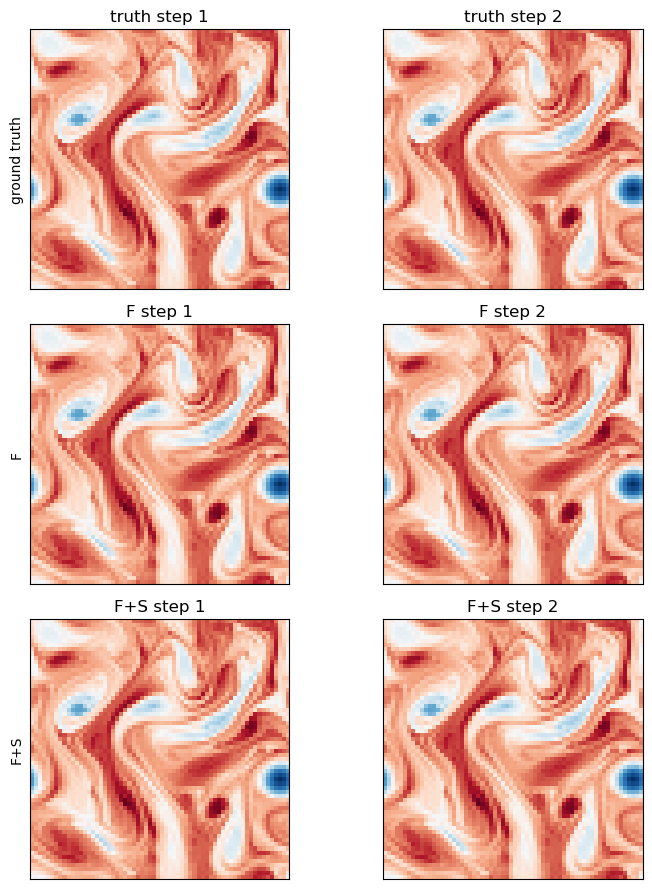

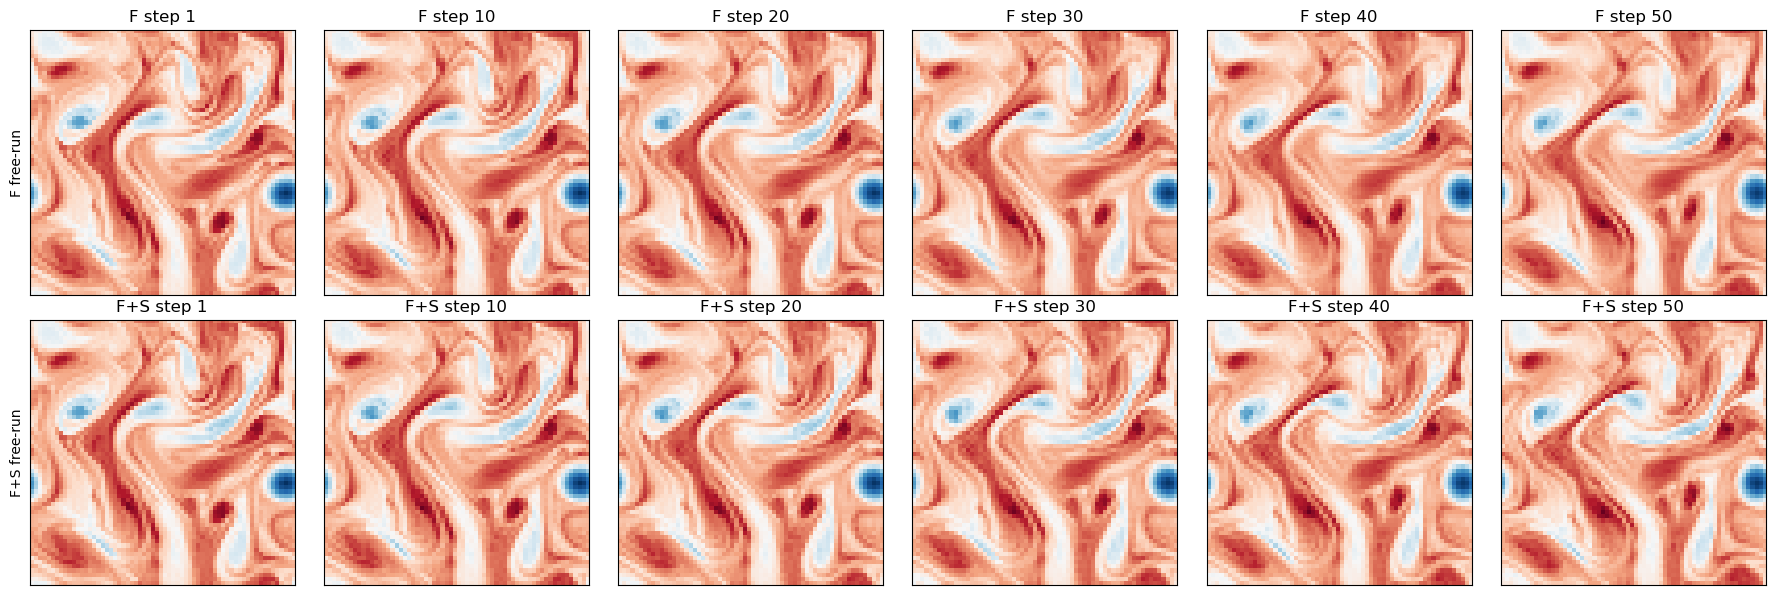

saved: /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data/rollout_results_traj0.npz


In [18]:
# =========================
# Self-contained inference cell
# =========================

import numpy as np
import torch
import matplotlib.pyplot as plt

model_F.eval()
model_S.eval()

@torch.no_grad()
def rollout_from_seed(traj, use_stabilizer=False, free_run_steps=2):
    """
    traj: [5, C, H, W] numpy array
    returns: [free_run_steps, C, H, W]
    """
    u_tm2 = torch.from_numpy(traj[0:1]).to(DEVICE)   # [1,C,H,W]
    u_tm1 = torch.from_numpy(traj[1:2]).to(DEVICE)
    u_t   = torch.from_numpy(traj[2:3]).to(DEVICE)

    pe = torch.from_numpy(PE[None]).to(DEVICE)       # [1,PE,H,W]

    scalars_list = [Lx, Ly, DT]
    if INCLUDE_DXY_SCALARS:
        scalars_list.extend([dx, dy])
    scalars = torch.tensor(scalars_list, dtype=torch.float32, device=DEVICE)[None]  # [1,S]

    preds = []

    for _ in range(free_run_steps):
        # normalize history
        u_tm2_n = (u_tm2 - u_mean) / u_std
        u_tm1_n = (u_tm1 - u_mean) / u_std
        u_t_n   = (u_t   - u_mean) / u_std

        # forecaster
        xF = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
        du_base_n = model_F(xF, scalars)
        du_base = du_base_n * du_std + du_mean

        if use_stabilizer:
            if INCLUDE_DU_BASE:
                xS = torch.cat([u_tm2_n, u_tm1_n, u_t_n, du_base_n, pe], dim=1)
            else:
                xS = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)

            du_corr_n = model_S(xS, scalars)
            du_corr = du_corr_n * du_std
        else:
            du_corr = torch.zeros_like(du_base)

        u_next = u_t + du_base + du_corr
        preds.append(u_next.squeeze(0).cpu().numpy().copy())

        # shift autoregressive history
        u_tm2, u_tm1, u_t = u_tm1, u_t, u_next

    return np.stack(preds, axis=0)

# -------------------------
# choose trajectory
# -------------------------
traj = test_traj[TEST_TRAJ_ID]      # [5,C,H,W]
truth_future = traj[3:5]            # only 2 GT future steps exist

# predictions for GT-supported horizon
pred_F = rollout_from_seed(traj, use_stabilizer=False, free_run_steps=2)
pred_FS = rollout_from_seed(traj, use_stabilizer=True, free_run_steps=2)

# long free-run predictions
pred_F_long = rollout_from_seed(traj, use_stabilizer=False, free_run_steps=LONG_FREE_RUN_STEPS)
pred_FS_long = rollout_from_seed(traj, use_stabilizer=True, free_run_steps=LONG_FREE_RUN_STEPS)

# RMSE on the only truth-supported horizon
rmse_F = np.sqrt(((pred_F - truth_future) ** 2).mean(axis=(1, 2, 3)))
rmse_FS = np.sqrt(((pred_FS - truth_future) ** 2).mean(axis=(1, 2, 3)))

print("RMSE F   :", rmse_F)
print("RMSE F+S :", rmse_FS)

# -------------------------
# truth vs prediction plot
# -------------------------
compare_steps = 2
fig, axes = plt.subplots(3, compare_steps, figsize=(4 * compare_steps, 9))

vmin = min(
    truth_future[:, 0].min(),
    pred_F[:, 0].min(),
    pred_FS[:, 0].min(),
)
vmax = max(
    truth_future[:, 0].max(),
    pred_F[:, 0].max(),
    pred_FS[:, 0].max(),
)

for s in range(compare_steps):
    axes[0, s].imshow(truth_future[s, 0], cmap="RdBu_r", vmin=vmin, vmax=vmax)
    axes[0, s].set_title(f"truth step {s+1}")

    axes[1, s].imshow(pred_F[s, 0], cmap="RdBu_r", vmin=vmin, vmax=vmax)
    axes[1, s].set_title(f"F step {s+1}")

    axes[2, s].imshow(pred_FS[s, 0], cmap="RdBu_r", vmin=vmin, vmax=vmax)
    axes[2, s].set_title(f"F+S step {s+1}")

    for r in range(3):
        axes[r, s].set_xticks([])
        axes[r, s].set_yticks([])

axes[0, 0].set_ylabel("ground truth")
axes[1, 0].set_ylabel("F")
axes[2, 0].set_ylabel("F+S")
plt.tight_layout()
plt.show()

# -------------------------
# long free-run plot
# -------------------------
snap_ids = np.linspace(0, LONG_FREE_RUN_STEPS - 1, 6, dtype=int)
fig, axes = plt.subplots(2, len(snap_ids), figsize=(3 * len(snap_ids), 6))

vmin_long = min(pred_F_long[:, 0].min(), pred_FS_long[:, 0].min())
vmax_long = max(pred_F_long[:, 0].max(), pred_FS_long[:, 0].max())

for j, s in enumerate(snap_ids):
    axes[0, j].imshow(pred_F_long[s, 0], cmap="RdBu_r", vmin=vmin_long, vmax=vmax_long)
    axes[0, j].set_title(f"F step {s+1}")
    axes[0, j].set_xticks([])
    axes[0, j].set_yticks([])

    axes[1, j].imshow(pred_FS_long[s, 0], cmap="RdBu_r", vmin=vmin_long, vmax=vmax_long)
    axes[1, j].set_title(f"F+S step {s+1}")
    axes[1, j].set_xticks([])
    axes[1, j].set_yticks([])

axes[0, 0].set_ylabel("F free-run")
axes[1, 0].set_ylabel("F+S free-run")
plt.tight_layout()
plt.show()

# -------------------------
# save
# -------------------------
np.savez(
    RUN_DIR / "rollout_results_traj0.npz",
    traj=traj,
    truth_future=truth_future,
    pred_F=pred_F,
    pred_FS=pred_FS,
    pred_F_long=pred_F_long,
    pred_FS_long=pred_FS_long,
    rmse_F=rmse_F,
    rmse_FS=rmse_FS,
)
print("saved:", RUN_DIR / "rollout_results_traj0.npz")

In [ ]:
# quick summary on val/test after training
val_F = rollout_eval_metrics(val_loader, use_stabilizer=False, max_batches=MAX_VAL_BATCHES)
val_FS = rollout_eval_metrics(val_loader, use_stabilizer=True, max_batches=MAX_VAL_BATCHES)

test_F = rollout_eval_metrics(test_loader, use_stabilizer=False, max_batches=MAX_VAL_BATCHES)
test_FS = rollout_eval_metrics(test_loader, use_stabilizer=True, max_batches=MAX_VAL_BATCHES)

print("val F   :", json.dumps(val_F, indent=2))
print("val F+S :", json.dumps(val_FS, indent=2))
print("test F   :", json.dumps(test_F, indent=2))
print("test F+S :", json.dumps(test_FS, indent=2))

DEVICE = cuda
DATA_FILE = /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/output_data.pkl
F_CKPT = /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data/F_best.pt
S_CKPT = /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data/S_best.pt
data shape after channel add: (20000, 5, 1, 64, 64)
DT = 0.001 dx = 0.015625 dy = 0.015625
train: (16000, 5, 1, 64, 64)
val  : (2000, 5, 1, 64, 64)
test : (2000, 5, 1, 64, 64)
u_mean shape: (1, 1, 1, 1)
u_std shape : (1, 1, 1, 1)
Loaded F and S checkpoints successfully


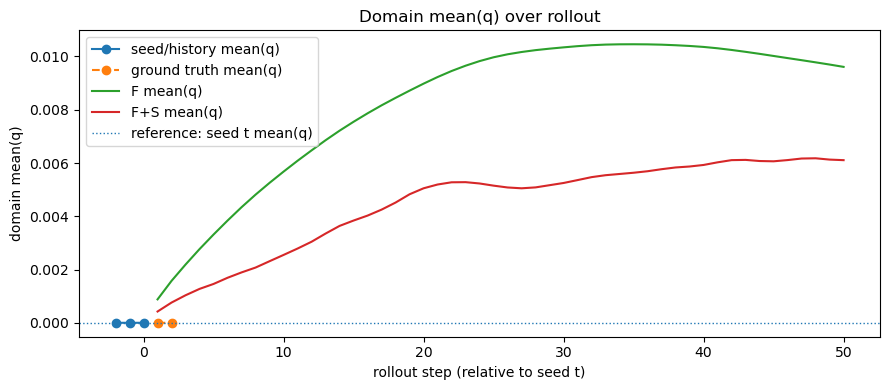

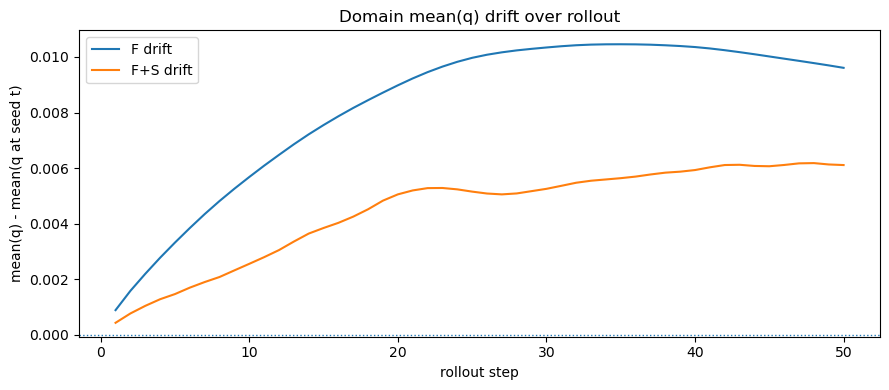

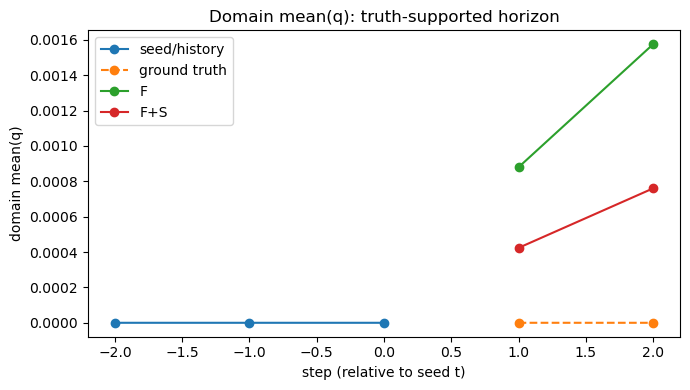

seed/history mean(q): [2.0861626e-07 2.3841858e-07 2.0861626e-07]
truth future mean(q): [2.6822090e-07 2.0861626e-07]
F first 10 mean(q): [0.00088005 0.00157534 0.00218804 0.0027685  0.00331502 0.00383881
 0.00434072 0.00481234 0.00525521 0.00567669]
F+S first 10 mean(q): [0.00042392 0.00076038 0.00103399 0.00127327 0.00145897 0.00169082
 0.00189218 0.0020743  0.00231268 0.00254849]

reference mean(q) at seed t: 2.086162567138672e-07
F max abs drift over long rollout   : 0.010458514094352722
F+S max abs drift over long rollout : 0.006177157163619995
F step1/2 abs error vs truth mean(q)   : [0.00087978 0.00157513]
F+S step1/2 abs error vs truth mean(q) : [0.00042365 0.00076017]
saved: /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data/domain_mean_q_check_traj0.npz


In [3]:
# ============================================================
# Standalone domain-mean(q) stability check cell
# Loads data + checkpoints from disk and runs independently
# ============================================================

import pickle
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------
# user config
# -----------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1337

DATA_FILE = Path("/scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/output_data.pkl")
RUN_DIR   = Path("/scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data")

F_CKPT = RUN_DIR / "F_best.pt"
S_CKPT = RUN_DIR / "S_best.pt"

TEST_TRAJ_ID = 0
LONG_FREE_RUN_STEPS = 50

# if you trained with different values, edit here
Lx = 1.0
Ly = 1.0
INCLUDE_DXY_SCALARS = True
INCLUDE_DU_BASE = True
NORM_TYPE = "batch"
FREQS = (1, 2, 4, 8)

# reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("DEVICE =", DEVICE)
print("DATA_FILE =", DATA_FILE)
print("F_CKPT =", F_CKPT)
print("S_CKPT =", S_CKPT)

# -----------------------
# helper functions
# -----------------------
def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def posenc_2d(H, W, Lx, Ly, freqs):
    xs = (np.arange(W, dtype=np.float32) + 0.5) * (Lx / W)
    ys = (np.arange(H, dtype=np.float32) + 0.5) * (Ly / H)

    chans = []
    for f in freqs:
        chans.append(np.sin(2.0 * np.pi * f * xs / max(Lx, 1e-8))[None, :].repeat(H, axis=0))
        chans.append(np.cos(2.0 * np.pi * f * xs / max(Lx, 1e-8))[None, :].repeat(H, axis=0))
    for f in freqs:
        chans.append(np.sin(2.0 * np.pi * f * ys / max(Ly, 1e-8))[:, None].repeat(W, axis=1))
        chans.append(np.cos(2.0 * np.pi * f * ys / max(Ly, 1e-8))[:, None].repeat(W, axis=1))

    return np.stack(chans, axis=0).astype(np.float32)

def domain_mean_over_xy(arr):
    arr = np.asarray(arr)
    if arr.ndim == 4:   # [T,C,H,W]
        return arr.mean(axis=(-2, -1))   # [T,C]
    elif arr.ndim == 3: # [C,H,W]
        return arr.mean(axis=(-2, -1))   # [C]
    else:
        raise ValueError(f"Unexpected shape for domain mean: {arr.shape}")

# -----------------------
# model definitions
# -----------------------
class BatchOrLayerNorm2d(nn.Module):
    def __init__(self, num_features, norm_type="batch"):
        super().__init__()
        if norm_type == "batch":
            self.norm = nn.BatchNorm2d(num_features)
        elif norm_type == "layer":
            self.norm = nn.GroupNorm(1, num_features)
        else:
            raise ValueError("norm_type must be 'batch' or 'layer'")

    def forward(self, x):
        return self.norm(x)

class ResidualDilated2D(nn.Module):
    def __init__(self, ch, d, norm_type="batch", dropout_p=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, kernel_size=3, padding=d, dilation=d, padding_mode="circular", bias=False)
        self.norm1 = BatchOrLayerNorm2d(ch, norm_type)
        self.act1 = nn.SiLU(inplace=True)
        self.drop1 = nn.Dropout2d(dropout_p)

        self.conv2 = nn.Conv2d(ch, ch, kernel_size=3, padding=1, padding_mode="circular", bias=False)
        self.norm2 = BatchOrLayerNorm2d(ch, norm_type)
        self.act2 = nn.SiLU(inplace=True)
        self.drop2 = nn.Dropout2d(dropout_p)

    def forward(self, x):
        y = self.drop1(self.act1(self.norm1(self.conv1(x))))
        y = self.drop2(self.norm2(self.conv2(y)))
        return self.act2(x + y)

class Forecaster2D(nn.Module):
    def __init__(self, cin, scalar_dim, cout, hidden=96, norm_type="batch", dropout_p=0.1, du_clip_n=5.0):
        super().__init__()
        self.du_clip_n = float(du_clip_n)

        self.stem = nn.Sequential(
            nn.Conv2d(cin, hidden, kernel_size=3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
        )

        self.b1 = ResidualDilated2D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated2D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated2D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated2D(hidden, 8, norm_type, dropout_p)
        self.b5 = ResidualDilated2D(hidden, 16, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(128, 32),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv2d(hidden + 32, hidden, kernel_size=1),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(hidden, cout, kernel_size=1),
        )

    def forward(self, x, scalars):
        h = self.stem(x)
        h = self.b5(self.b4(self.b3(self.b2(self.b1(h)))))

        B, _, Hh, Wh = h.shape
        s = self.scalar_proj(scalars)[:, :, None, None].expand(B, 32, Hh, Wh)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)

        c = self.du_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out

class Stabilizer2D(nn.Module):
    def __init__(self, cin, scalar_dim, cout, hidden=96, norm_type="batch", dropout_p=0.1, du_corr_clip_n=2.0):
        super().__init__()
        self.du_corr_clip_n = float(du_corr_clip_n)

        self.stem = nn.Sequential(
            nn.Conv2d(cin, hidden, kernel_size=3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
        )

        self.b1 = ResidualDilated2D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated2D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated2D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated2D(hidden, 8, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 64),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(64, 16),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv2d(hidden + 16, hidden, kernel_size=1),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(hidden, cout, kernel_size=1),
        )

    def forward(self, x, scalars):
        h = self.stem(x)
        h = self.b4(self.b3(self.b2(self.b1(h))))

        B, _, Hh, Wh = h.shape
        s = self.scalar_proj(scalars)[:, :, None, None].expand(B, 16, Hh, Wh)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)

        c = self.du_corr_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out

# -----------------------
# load data
# -----------------------
with open(DATA_FILE, "rb") as f:
    obj = pickle.load(f)

data_config = obj["data_config"]
data = to_numpy(obj["data"]).astype(np.float32)   # [N, T, H, W]
assert data.ndim == 4, f"expected [N,T,H,W], got {data.shape}"

N, T, H, W = data.shape
data = data[:, :, None, :, :]   # [N,T,C,H,W]
N, T, C, H, W = data.shape

DT = float(data_config["dt"]) if "dt" in data_config else 1.0
dx = Lx / W
dy = Ly / H

print("data shape after channel add:", data.shape)
print("DT =", DT, "dx =", dx, "dy =", dy)

# same split logic as training notebook
perm = np.random.RandomState(SEED).permutation(N)
n_train = int(0.80 * N)
n_val   = int(0.10 * N)

idx_train = perm[:n_train]
idx_val   = perm[n_train:n_train+n_val]
idx_test  = perm[n_train+n_val:]

train_traj = data[idx_train]
val_traj   = data[idx_val]
test_traj  = data[idx_test]

print("train:", train_traj.shape)
print("val  :", val_traj.shape)
print("test :", test_traj.shape)

# -----------------------
# recompute norms from train split
# -----------------------
u_mean_np = train_traj.mean(axis=(0, 1, 3, 4), keepdims=False).astype(np.float32)
u_std_np  = (train_traj.std(axis=(0, 1, 3, 4), keepdims=False) + 1e-6).astype(np.float32)

du = train_traj[:, 1:] - train_traj[:, :-1]
du_mean_np = du.mean(axis=(0, 1, 3, 4), keepdims=False).astype(np.float32)
du_std_np  = (du.std(axis=(0, 1, 3, 4), keepdims=False) + 1e-6).astype(np.float32)

u_mean = torch.from_numpy(u_mean_np.reshape(1, -1, 1, 1)).to(DEVICE)
u_std  = torch.from_numpy(u_std_np.reshape(1, -1, 1, 1)).to(DEVICE)
du_mean = torch.from_numpy(du_mean_np.reshape(1, -1, 1, 1)).to(DEVICE)
du_std  = torch.from_numpy(du_std_np.reshape(1, -1, 1, 1)).to(DEVICE)

print("u_mean shape:", tuple(u_mean.shape))
print("u_std shape :", tuple(u_std.shape))

# -----------------------
# load checkpoints and rebuild models
# -----------------------
ckpt_F = torch.load(F_CKPT, map_location=DEVICE)
ckpt_S = torch.load(S_CKPT, map_location=DEVICE)

cfg_F = ckpt_F.get("config", {})
cfg_S = ckpt_S.get("config", {})

PE = posenc_2d(H, W, Lx, Ly, FREQS)
PE_CH = PE.shape[0]

Sdim = 3 + (2 if INCLUDE_DXY_SCALARS else 0)
Cin_F = int(cfg_F.get("Cin_F", 3 * C + PE_CH))
Cin_S = int(cfg_S.get("Cin_S", 3 * C + (C if INCLUDE_DU_BASE else 0) + PE_CH))

HIDDEN_F = int(cfg_F.get("hidden_f", 96))
DU_CLIP_N = float(cfg_F.get("du_clip_n", 5.0))

HIDDEN_S = int(cfg_S.get("hidden_s", 96))
DU_CORR_CLIP_N = float(cfg_S.get("du_corr_clip_n", 2.0))

model_F = Forecaster2D(
    cin=Cin_F,
    scalar_dim=Sdim,
    cout=C,
    hidden=HIDDEN_F,
    norm_type=NORM_TYPE,
    dropout_p=0.0,
    du_clip_n=DU_CLIP_N,
).to(DEVICE)

model_S = Stabilizer2D(
    cin=Cin_S,
    scalar_dim=Sdim,
    cout=C,
    hidden=HIDDEN_S,
    norm_type=NORM_TYPE,
    dropout_p=0.0,
    du_corr_clip_n=DU_CORR_CLIP_N,
).to(DEVICE)

model_F.load_state_dict(ckpt_F["F"], strict=True)
model_S.load_state_dict(ckpt_S["S"], strict=True)

model_F.eval()
model_S.eval()

print("Loaded F and S checkpoints successfully")

# -----------------------
# rollout function
# -----------------------
@torch.no_grad()
def rollout_from_seed(traj, use_stabilizer=False, free_run_steps=50):
    """
    traj: [5,C,H,W]
    returns: [free_run_steps, C, H, W]
    """
    u_tm2 = torch.from_numpy(traj[0:1]).to(DEVICE)  # [1,C,H,W]
    u_tm1 = torch.from_numpy(traj[1:2]).to(DEVICE)
    u_t   = torch.from_numpy(traj[2:3]).to(DEVICE)

    pe = torch.from_numpy(PE[None]).to(DEVICE)      # [1,PE,H,W]

    scalars_list = [Lx, Ly, DT]
    if INCLUDE_DXY_SCALARS:
        scalars_list.extend([dx, dy])
    scalars = torch.tensor(scalars_list, dtype=torch.float32, device=DEVICE)[None]

    preds = []

    for _ in range(free_run_steps):
        u_tm2_n = (u_tm2 - u_mean) / u_std
        u_tm1_n = (u_tm1 - u_mean) / u_std
        u_t_n   = (u_t   - u_mean) / u_std

        xF = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
        du_base_n = model_F(xF, scalars)
        du_base = du_base_n * du_std + du_mean

        if use_stabilizer:
            if INCLUDE_DU_BASE:
                xS = torch.cat([u_tm2_n, u_tm1_n, u_t_n, du_base_n, pe], dim=1)
            else:
                xS = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
            du_corr_n = model_S(xS, scalars)
            du_corr = du_corr_n * du_std
        else:
            du_corr = torch.zeros_like(du_base)

        u_next = u_t + du_base + du_corr
        preds.append(u_next.squeeze(0).cpu().numpy().copy())

        u_tm2, u_tm1, u_t = u_tm1, u_t, u_next

    return np.stack(preds, axis=0)

# -----------------------
# choose test trajectory and run rollout
# -----------------------
traj = test_traj[TEST_TRAJ_ID]    # [5,C,H,W]
truth_future = traj[3:5]          # only 2 GT future steps exist

pred_F_long = rollout_from_seed(traj, use_stabilizer=False, free_run_steps=LONG_FREE_RUN_STEPS)
pred_FS_long = rollout_from_seed(traj, use_stabilizer=True, free_run_steps=LONG_FREE_RUN_STEPS)

# domain means
seed_means = domain_mean_over_xy(traj[:3])[:, 0]          # [3]
truth_means = domain_mean_over_xy(truth_future)[:, 0]     # [2]
F_means_long = domain_mean_over_xy(pred_F_long)[:, 0]     # [steps]
FS_means_long = domain_mean_over_xy(pred_FS_long)[:, 0]   # [steps]

ref_mean = float(seed_means[-1])

# -----------------------
# plot 1: full long rollout
# -----------------------
plt.figure(figsize=(9, 4))

x_seed = np.array([-2, -1, 0])
x_truth = np.array([1, 2])
x_roll = np.arange(1, LONG_FREE_RUN_STEPS + 1)

plt.plot(x_seed, seed_means, marker="o", label="seed/history mean(q)")
plt.plot(x_truth, truth_means, marker="o", linestyle="--", label="ground truth mean(q)")
plt.plot(x_roll, F_means_long, label="F mean(q)")
plt.plot(x_roll, FS_means_long, label="F+S mean(q)")
plt.axhline(ref_mean, linestyle=":", linewidth=1, label="reference: seed t mean(q)")

plt.xlabel("rollout step (relative to seed t)")
plt.ylabel("domain mean(q)")
plt.title("Domain mean(q) over rollout")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------
# plot 2: drift from seed-t mean
# -----------------------
plt.figure(figsize=(9, 4))
plt.plot(x_roll, F_means_long - ref_mean, label="F drift")
plt.plot(x_roll, FS_means_long - ref_mean, label="F+S drift")
plt.axhline(0.0, linestyle=":", linewidth=1)
plt.xlabel("rollout step")
plt.ylabel("mean(q) - mean(q at seed t)")
plt.title("Domain mean(q) drift over rollout")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------
# plot 3: zoom into truth-supported horizon
# -----------------------
plt.figure(figsize=(7, 4))
plt.plot(x_seed, seed_means, marker="o", label="seed/history")
plt.plot(x_truth, truth_means, marker="o", linestyle="--", label="ground truth")
plt.plot(x_truth, F_means_long[:2], marker="o", label="F")
plt.plot(x_truth, FS_means_long[:2], marker="o", label="F+S")
plt.xlabel("step (relative to seed t)")
plt.ylabel("domain mean(q)")
plt.title("Domain mean(q): truth-supported horizon")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------
# diagnostics
# -----------------------
print("seed/history mean(q):", seed_means)
print("truth future mean(q):", truth_means)
print("F first 10 mean(q):", F_means_long[:10])
print("F+S first 10 mean(q):", FS_means_long[:10])
print()
print("reference mean(q) at seed t:", ref_mean)
print("F max abs drift over long rollout   :", float(np.max(np.abs(F_means_long - ref_mean))))
print("F+S max abs drift over long rollout :", float(np.max(np.abs(FS_means_long - ref_mean))))
print("F step1/2 abs error vs truth mean(q)   :", np.abs(F_means_long[:2] - truth_means))
print("F+S step1/2 abs error vs truth mean(q) :", np.abs(FS_means_long[:2] - truth_means))

# -----------------------
# save
# -----------------------
out_path = RUN_DIR / f"domain_mean_q_check_traj{TEST_TRAJ_ID}.npz"
np.savez(
    out_path,
    traj=traj,
    truth_future=truth_future,
    seed_means=seed_means,
    truth_means=truth_means,
    F_means_long=F_means_long,
    FS_means_long=FS_means_long,
    ref_mean=ref_mean,
)
print("saved:", out_path)

DEVICE = cuda
Loaded F and S checkpoints successfully
k-spectrum comparison at rollout step: 199
k_ic min/max: 6.589852297075297 271.11218196809585
k_F  min/max: 6.589852297075297 271.11218196809585
k_FS min/max: 6.589852297075297 271.11218196809585


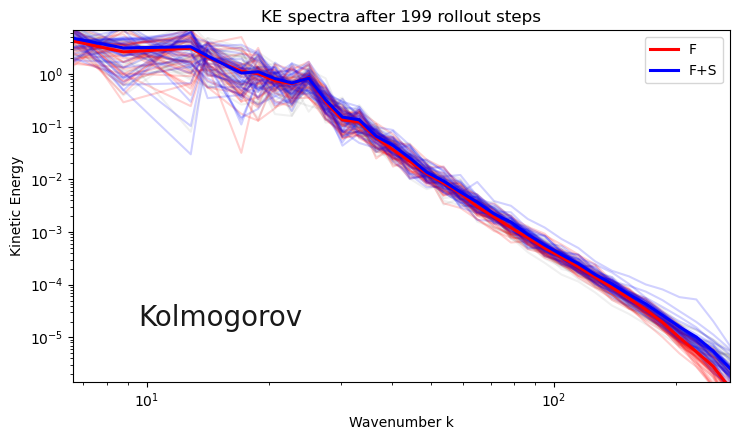

saved figure: /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data/ke_spectra_overlay_step_199.png
saved data  : /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data/ke_spectra_overlay_step_199.npz


In [4]:
# ============================================================
# Standalone KE plot reworked to look like img2:
# one aggregate panel with many overlaid trajectories
# ============================================================

import pickle
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------
# user config
# -----------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1337

DATA_FILE = Path("/scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/output_data.pkl")
RUN_DIR   = Path("/scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data")

F_CKPT = RUN_DIR / "F_best.pt"
S_CKPT = RUN_DIR / "S_best.pt"

N_PLOT_TRAJS = 32
FREE_RUN_STEPS = 200
PLOT_STEP = 199   # final rollout step to compare, like a long-time KE panel

Lx = 1.0
Ly = 1.0
INCLUDE_DXY_SCALARS = True
INCLUDE_DU_BASE = True
NORM_TYPE = "batch"
FREQS = (1, 2, 4, 8)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("DEVICE =", DEVICE)

# -----------------------
# helpers
# -----------------------
def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def posenc_2d(H, W, Lx, Ly, freqs):
    xs = (np.arange(W, dtype=np.float32) + 0.5) * (Lx / W)
    ys = (np.arange(H, dtype=np.float32) + 0.5) * (Ly / H)

    chans = []
    for f in freqs:
        chans.append(np.sin(2.0 * np.pi * f * xs / max(Lx, 1e-8))[None, :].repeat(H, axis=0))
        chans.append(np.cos(2.0 * np.pi * f * xs / max(Lx, 1e-8))[None, :].repeat(H, axis=0))
    for f in freqs:
        chans.append(np.sin(2.0 * np.pi * f * ys / max(Ly, 1e-8))[:, None].repeat(W, axis=1))
        chans.append(np.cos(2.0 * np.pi * f * ys / max(Ly, 1e-8))[:, None].repeat(W, axis=1))
    return np.stack(chans, axis=0).astype(np.float32)

def get_ke_batch_from_vorticity_physical_k(batch_fields, Lx=1.0, Ly=1.0, eps=1e-12):
    """
    batch_fields: [B,H,W] or [B,1,H,W]
    returns:
        k_shell: [K]
        E_shell: [B,K]
    """
    arr = np.asarray(batch_fields, dtype=np.float64)
    if arr.ndim == 4:
        arr = arr[:, 0]
    assert arr.ndim == 3, f"expected [B,H,W], got {arr.shape}"

    B, H, W = arr.shape

    kx = 2.0 * np.pi * np.fft.fftfreq(W, d=Lx / W)
    ky = 2.0 * np.pi * np.fft.fftfreq(H, d=Ly / H)
    KX, KY = np.meshgrid(kx, ky, indexing="xy")
    KR = np.sqrt(KX**2 + KY**2)
    K2 = KX**2 + KY**2

    w_hat = np.fft.fft2(arr, axes=(-2, -1), norm="ortho")

    K2_safe = K2.copy()
    K2_safe[0, 0] = np.inf
    psi_hat = -w_hat / K2_safe[None, :, :]
    psi_hat[:, 0, 0] = 0.0

    u_hat = 1j * KY[None, :, :] * psi_hat
    v_hat = -1j * KX[None, :, :] * psi_hat
    E2D = 0.5 * (np.abs(u_hat) ** 2 + np.abs(v_hat) ** 2)

    kr_positive = KR[KR > 0]
    kmin = float(np.min(kr_positive))
    kmax = float(np.max(kr_positive))

    n_bins = 40
    bins = np.logspace(np.log10(kmin), np.log10(kmax), n_bins + 1)

    k_shell = []
    E_shell = []
    for i in range(n_bins):
        mask = (KR >= bins[i]) & (KR < bins[i + 1])
        if np.any(mask):
            k_shell.append(np.sqrt(bins[i] * bins[i + 1]))
            E_shell.append(E2D[:, mask].mean(axis=1))

    k_shell = np.asarray(k_shell, dtype=np.float64)
    E_shell = np.stack(E_shell, axis=1)
    E_shell = np.maximum(E_shell, eps)
    return k_shell, E_shell

# -----------------------
# model definitions
# -----------------------
class BatchOrLayerNorm2d(nn.Module):
    def __init__(self, num_features, norm_type="batch"):
        super().__init__()
        if norm_type == "batch":
            self.norm = nn.BatchNorm2d(num_features)
        elif norm_type == "layer":
            self.norm = nn.GroupNorm(1, num_features)
        else:
            raise ValueError("norm_type must be 'batch' or 'layer'")

    def forward(self, x):
        return self.norm(x)

class ResidualDilated2D(nn.Module):
    def __init__(self, ch, d, norm_type="batch", dropout_p=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=d, dilation=d, padding_mode="circular", bias=False)
        self.norm1 = BatchOrLayerNorm2d(ch, norm_type)
        self.act1 = nn.SiLU(inplace=True)
        self.drop1 = nn.Dropout2d(dropout_p)

        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, padding_mode="circular", bias=False)
        self.norm2 = BatchOrLayerNorm2d(ch, norm_type)
        self.act2 = nn.SiLU(inplace=True)
        self.drop2 = nn.Dropout2d(dropout_p)

    def forward(self, x):
        y = self.drop1(self.act1(self.norm1(self.conv1(x))))
        y = self.drop2(self.norm2(self.conv2(y)))
        return self.act2(x + y)

class Forecaster2D(nn.Module):
    def __init__(self, cin, scalar_dim, cout, hidden=96, norm_type="batch", dropout_p=0.0, du_clip_n=5.0):
        super().__init__()
        self.du_clip_n = float(du_clip_n)

        self.stem = nn.Sequential(
            nn.Conv2d(cin, hidden, kernel_size=3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
        )

        self.b1 = ResidualDilated2D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated2D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated2D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated2D(hidden, 8, norm_type, dropout_p)
        self.b5 = ResidualDilated2D(hidden, 16, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_p),   # keep this to match checkpoint
            nn.Linear(128, 32),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv2d(hidden + 32, hidden, kernel_size=1),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),  # keep this to match checkpoint
            nn.Conv2d(hidden, cout, kernel_size=1),
        )

    def forward(self, x, scalars):
        h = self.stem(x)
        h = self.b5(self.b4(self.b3(self.b2(self.b1(h)))))

        B, _, Hh, Wh = h.shape
        s = self.scalar_proj(scalars)[:, :, None, None].expand(B, 32, Hh, Wh)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)

        c = self.du_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out


class Stabilizer2D(nn.Module):
    def __init__(self, cin, scalar_dim, cout, hidden=96, norm_type="batch", dropout_p=0.0, du_corr_clip_n=2.0):
        super().__init__()
        self.du_corr_clip_n = float(du_corr_clip_n)

        self.stem = nn.Sequential(
            nn.Conv2d(cin, hidden, kernel_size=3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
        )

        self.b1 = ResidualDilated2D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated2D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated2D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated2D(hidden, 8, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 64),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_p),   # keep this to match checkpoint
            nn.Linear(64, 16),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv2d(hidden + 16, hidden, kernel_size=1),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),  # keep this to match checkpoint
            nn.Conv2d(hidden, cout, kernel_size=1),
        )

    def forward(self, x, scalars):
        h = self.stem(x)
        h = self.b4(self.b3(self.b2(self.b1(h))))

        B, _, Hh, Wh = h.shape
        s = self.scalar_proj(scalars)[:, :, None, None].expand(B, 16, Hh, Wh)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)

        c = self.du_corr_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out

# -----------------------
# load data
# -----------------------
with open(DATA_FILE, "rb") as f:
    obj = pickle.load(f)

data_config = obj["data_config"]
data = to_numpy(obj["data"]).astype(np.float32)  # [N,T,H,W]
N, T, H, W = data.shape
data = data[:, :, None, :, :]  # [N,T,C,H,W]
N, T, C, H, W = data.shape

DT = float(data_config["dt"]) if "dt" in data_config else 1.0
dx = Lx / W
dy = Ly / H

perm = np.random.RandomState(SEED).permutation(N)
n_train = int(0.80 * N)
n_val = int(0.10 * N)
idx_train = perm[:n_train]
idx_test = perm[n_train+n_val:]

train_traj = data[idx_train]
test_traj = data[idx_test]

# norms
u_mean_np = train_traj.mean(axis=(0, 1, 3, 4), keepdims=False).astype(np.float32)
u_std_np  = (train_traj.std(axis=(0, 1, 3, 4), keepdims=False) + 1e-6).astype(np.float32)
du = train_traj[:, 1:] - train_traj[:, :-1]
du_mean_np = du.mean(axis=(0, 1, 3, 4), keepdims=False).astype(np.float32)
du_std_np  = (du.std(axis=(0, 1, 3, 4), keepdims=False) + 1e-6).astype(np.float32)

u_mean = torch.from_numpy(u_mean_np.reshape(1, -1, 1, 1)).to(DEVICE)
u_std = torch.from_numpy(u_std_np.reshape(1, -1, 1, 1)).to(DEVICE)
du_mean = torch.from_numpy(du_mean_np.reshape(1, -1, 1, 1)).to(DEVICE)
du_std = torch.from_numpy(du_std_np.reshape(1, -1, 1, 1)).to(DEVICE)

# -----------------------
# load models
# -----------------------
ckpt_F = torch.load(F_CKPT, map_location=DEVICE)
ckpt_S = torch.load(S_CKPT, map_location=DEVICE)

cfg_F = ckpt_F.get("config", {})
cfg_S = ckpt_S.get("config", {})

PE = posenc_2d(H, W, Lx, Ly, FREQS)
PE_CH = PE.shape[0]

Sdim = 3 + (2 if INCLUDE_DXY_SCALARS else 0)
Cin_F = int(cfg_F.get("Cin_F", 3 * C + PE_CH))
Cin_S = int(cfg_S.get("Cin_S", 3 * C + (C if INCLUDE_DU_BASE else 0) + PE_CH))

HIDDEN_F = int(cfg_F.get("hidden_f", 96))
DU_CLIP_N = float(cfg_F.get("du_clip_n", 5.0))
HIDDEN_S = int(cfg_S.get("hidden_s", 96))
DU_CORR_CLIP_N = float(cfg_S.get("du_corr_clip_n", 2.0))

model_F = Forecaster2D(
    Cin_F, Sdim, C,
    hidden=HIDDEN_F,
    norm_type=NORM_TYPE,
    dropout_p=0.0,   # keep module structure, disable effect
    du_clip_n=DU_CLIP_N,
).to(DEVICE)

model_S = Stabilizer2D(
    Cin_S, Sdim, C,
    hidden=HIDDEN_S,
    norm_type=NORM_TYPE,
    dropout_p=0.0,   # keep module structure, disable effect
    du_corr_clip_n=DU_CORR_CLIP_N,
).to(DEVICE)

model_F.load_state_dict(ckpt_F["F"], strict=True)
model_S.load_state_dict(ckpt_S["S"], strict=True)

model_F.eval()
model_S.eval()
print("Loaded F and S checkpoints successfully")



# -----------------------
# rollout batch
# -----------------------
@torch.no_grad()
def rollout_batch(seed_trajs, use_stabilizer=False, free_run_steps=200):
    seed_trajs = np.asarray(seed_trajs, dtype=np.float32)
    B = seed_trajs.shape[0]

    u_tm2 = torch.from_numpy(seed_trajs[:, 0]).to(DEVICE)
    u_tm1 = torch.from_numpy(seed_trajs[:, 1]).to(DEVICE)
    u_t   = torch.from_numpy(seed_trajs[:, 2]).to(DEVICE)

    pe = torch.from_numpy(PE[None]).to(DEVICE).expand(B, -1, -1, -1)

    scalars_list = [Lx, Ly, DT]
    if INCLUDE_DXY_SCALARS:
        scalars_list.extend([dx, dy])
    scalars = torch.tensor(scalars_list, dtype=torch.float32, device=DEVICE)[None].expand(B, -1)

    preds = []
    for _ in range(free_run_steps):
        u_tm2_n = (u_tm2 - u_mean) / u_std
        u_tm1_n = (u_tm1 - u_mean) / u_std
        u_t_n   = (u_t   - u_mean) / u_std

        xF = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
        du_base_n = model_F(xF, scalars)
        du_base = du_base_n * du_std + du_mean

        if use_stabilizer:
            if INCLUDE_DU_BASE:
                xS = torch.cat([u_tm2_n, u_tm1_n, u_t_n, du_base_n, pe], dim=1)
            else:
                xS = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
            du_corr_n = model_S(xS, scalars)
            du_corr = du_corr_n * du_std
        else:
            du_corr = torch.zeros_like(du_base)

        u_next = u_t + du_base + du_corr
        preds.append(u_next.detach().cpu().numpy())
        u_tm2, u_tm1, u_t = u_tm1, u_t, u_next

    return np.stack(preds, axis=1)  # [B,steps,C,H,W]

# -----------------------
# rollout selected test trajectories
# -----------------------
n_use = min(N_PLOT_TRAJS, len(test_traj))
seed_batch = test_traj[:n_use]

pred_F = rollout_batch(seed_batch, use_stabilizer=False, free_run_steps=FREE_RUN_STEPS)
pred_FS = rollout_batch(seed_batch, use_stabilizer=True, free_run_steps=FREE_RUN_STEPS)

ic_fields = seed_batch[:, 2]
final_F = pred_F[:, PLOT_STEP]
final_FS = pred_FS[:, PLOT_STEP]

print("k-spectrum comparison at rollout step:", PLOT_STEP)

# spectra
k_ic, ke_ic = get_ke_batch_from_vorticity_physical_k(ic_fields, Lx=Lx, Ly=Ly)
k_F, ke_F = get_ke_batch_from_vorticity_physical_k(final_F, Lx=Lx, Ly=Ly)
k_FS, ke_FS = get_ke_batch_from_vorticity_physical_k(final_FS, Lx=Lx, Ly=Ly)

print("k_ic min/max:", k_ic.min(), k_ic.max())
print("k_F  min/max:", k_F.min(), k_F.max())
print("k_FS min/max:", k_FS.min(), k_FS.max())

# y range from actual spectra
all_pos = np.concatenate([ke_ic.reshape(-1), ke_F.reshape(-1), ke_FS.reshape(-1)])
all_pos = all_pos[np.isfinite(all_pos) & (all_pos > 0)]
ymin = max(np.percentile(all_pos, 1), 1e-12)
ymax = max(np.percentile(all_pos, 99), ymin * 10)

# -----------------------
# plot like img2
# -----------------------
fig = plt.figure(figsize=(7.5, 4.5))
ax = plt.gca()

# faint initial condition in black/gray
for i in range(ke_ic.shape[0]):
    ax.loglog(k_ic, ke_ic[i], color="black", alpha=0.06)

# F in red
for i in range(ke_F.shape[0]):
    ax.loglog(k_F, ke_F[i], color="red", alpha=0.18)

# F+S in blue
for i in range(ke_FS.shape[0]):
    ax.loglog(k_FS, ke_FS[i], color="blue", alpha=0.18)

# thicker mean curves
ax.loglog(k_F, ke_F.mean(axis=0), color="red", linewidth=2.2, label="F")
ax.loglog(k_FS, ke_FS.mean(axis=0), color="blue", linewidth=2.2, label="F+S")

ax.set_xlabel("Wavenumber k")
ax.set_ylabel("Kinetic Energy")
ax.set_title(f"KE spectra after {PLOT_STEP} rollout steps")
ax.set_xlim(k_ic.min(), k_ic.max())
ax.set_ylim(ymin, ymax)
ax.legend()

# optional in-panel label like img2
ax.text(
    0.10, 0.16, "Kolmogorov",
    transform=ax.transAxes,
    fontsize=20,
    color="black",
    alpha=0.9
)

plt.tight_layout()
plt.show()

# -----------------------
# save
# -----------------------
out_png = RUN_DIR / f"ke_spectra_overlay_step_{PLOT_STEP}.png"
fig.savefig(out_png, dpi=220, bbox_inches="tight")

out_npz = RUN_DIR / f"ke_spectra_overlay_step_{PLOT_STEP}.npz"
np.savez(
    out_npz,
    k_ic=k_ic,
    ke_ic=ke_ic,
    k_F=k_F,
    ke_F=ke_F,
    k_FS=k_FS,
    ke_FS=ke_FS,
    plot_step=PLOT_STEP,
)

print("saved figure:", out_png)
print("saved data  :", out_npz)

DEVICE = cuda
DATA_FILE = /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/output_data.pkl
F_CKPT = /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data/F_best.pt
S_CKPT = /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data/S_best.pt
loaded data shape: (20000, 5, 1, 64, 64)
DT = 0.001 dx = 0.015625 dy = 0.015625
train: (16000, 5, 1, 64, 64)
test : (2000, 5, 1, 64, 64)
u_mean shape: (1, 1, 1, 1)
u_std shape : (1, 1, 1, 1)
Loaded F and S checkpoints successfully


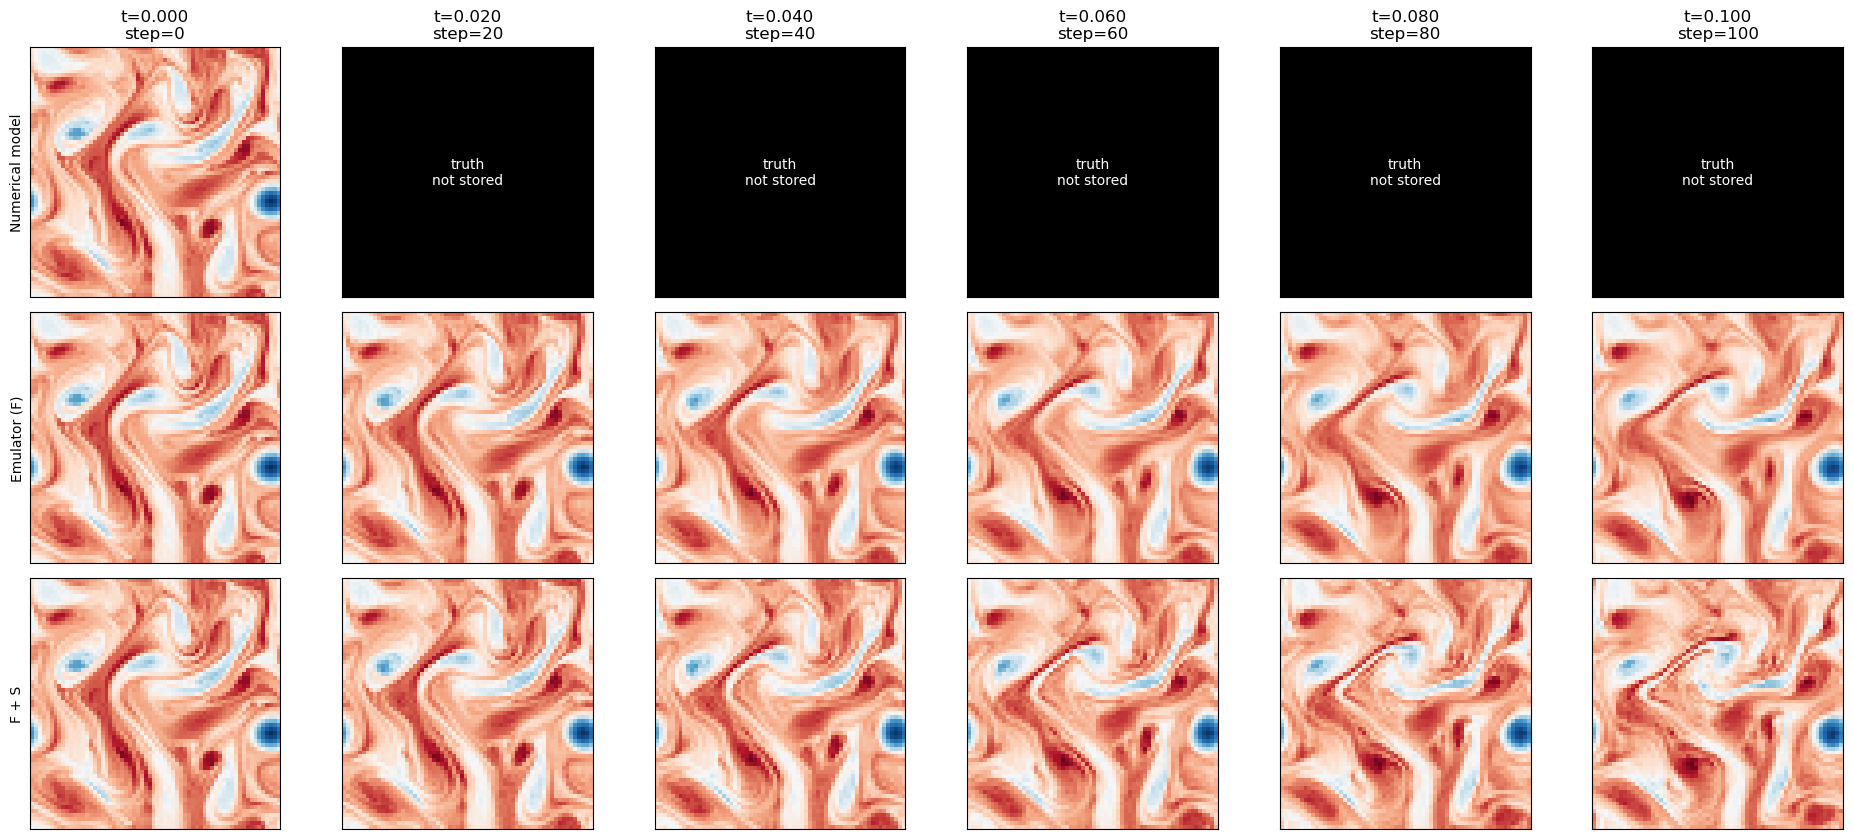

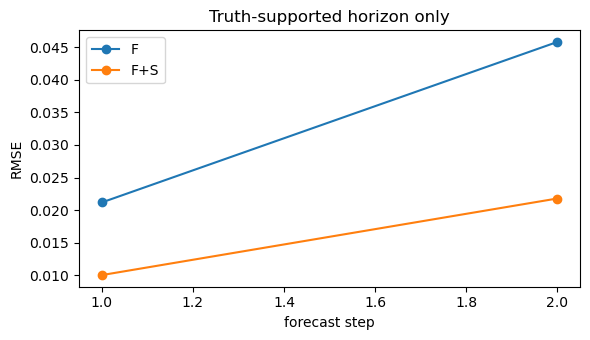

RMSE F over available truth steps   : [0.02119702 0.04579001]
RMSE F+S over available truth steps : [0.01005797 0.02179469]
saved: /scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data/figure3_style_rollout_traj0.npz


In [2]:
# ============================================================
# Standalone Figure-3-style rollout cell
# Loads everything from disk and runs independently
# ============================================================

import pickle
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------
# user config
# -----------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1337

DATA_FILE = Path("/scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/output_data.pkl")
RUN_DIR   = Path("/scratch/pp3051/weather/main_repo/Data_2D_Thermalizer/runs_exp11_2d_from_output_data")

F_CKPT = RUN_DIR / "F_best.pt"
S_CKPT = RUN_DIR / "S_best.pt"

TEST_TRAJ_ID = 0

# rollout display settings
ROLLOUT_STEPS = 100
SNAPSHOT_STEPS = [0, 20, 40, 60, 80, 100]
CHANNEL_TO_SHOW = 0
CMAP = "RdBu_r"

# model/data settings used in your notebook
Lx = 1.0
Ly = 1.0
INCLUDE_DXY_SCALARS = True
INCLUDE_DU_BASE = True
NORM_TYPE = "batch"
FREQS = (1, 2, 4, 8)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("DEVICE =", DEVICE)
print("DATA_FILE =", DATA_FILE)
print("F_CKPT =", F_CKPT)
print("S_CKPT =", S_CKPT)

# -----------------------
# helpers
# -----------------------
def to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def posenc_2d(H, W, Lx, Ly, freqs):
    xs = (np.arange(W, dtype=np.float32) + 0.5) * (Lx / W)
    ys = (np.arange(H, dtype=np.float32) + 0.5) * (Ly / H)

    chans = []
    for f in freqs:
        chans.append(np.sin(2.0 * np.pi * f * xs / max(Lx, 1e-8))[None, :].repeat(H, axis=0))
        chans.append(np.cos(2.0 * np.pi * f * xs / max(Lx, 1e-8))[None, :].repeat(H, axis=0))
    for f in freqs:
        chans.append(np.sin(2.0 * np.pi * f * ys / max(Ly, 1e-8))[:, None].repeat(W, axis=1))
        chans.append(np.cos(2.0 * np.pi * f * ys / max(Ly, 1e-8))[:, None].repeat(W, axis=1))
    return np.stack(chans, axis=0).astype(np.float32)

# -----------------------
# model definitions
# -----------------------
class BatchOrLayerNorm2d(nn.Module):
    def __init__(self, num_features, norm_type="batch"):
        super().__init__()
        if norm_type == "batch":
            self.norm = nn.BatchNorm2d(num_features)
        elif norm_type == "layer":
            self.norm = nn.GroupNorm(1, num_features)
        else:
            raise ValueError("norm_type must be 'batch' or 'layer'")

    def forward(self, x):
        return self.norm(x)

class ResidualDilated2D(nn.Module):
    def __init__(self, ch, d, norm_type="batch", dropout_p=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, kernel_size=3, padding=d, dilation=d, padding_mode="circular", bias=False)
        self.norm1 = BatchOrLayerNorm2d(ch, norm_type)
        self.act1 = nn.SiLU(inplace=True)
        self.drop1 = nn.Dropout2d(dropout_p)

        self.conv2 = nn.Conv2d(ch, ch, kernel_size=3, padding=1, padding_mode="circular", bias=False)
        self.norm2 = BatchOrLayerNorm2d(ch, norm_type)
        self.act2 = nn.SiLU(inplace=True)
        self.drop2 = nn.Dropout2d(dropout_p)

    def forward(self, x):
        y = self.drop1(self.act1(self.norm1(self.conv1(x))))
        y = self.drop2(self.norm2(self.conv2(y)))
        return self.act2(x + y)

class Forecaster2D(nn.Module):
    def __init__(self, cin, scalar_dim, cout, hidden=96, norm_type="batch", dropout_p=0.1, du_clip_n=5.0):
        super().__init__()
        self.du_clip_n = float(du_clip_n)

        self.stem = nn.Sequential(
            nn.Conv2d(cin, hidden, kernel_size=3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
        )

        self.b1 = ResidualDilated2D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated2D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated2D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated2D(hidden, 8, norm_type, dropout_p)
        self.b5 = ResidualDilated2D(hidden, 16, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(128, 32),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv2d(hidden + 32, hidden, kernel_size=1),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(hidden, cout, kernel_size=1),
        )

    def forward(self, x, scalars):
        h = self.stem(x)
        h = self.b5(self.b4(self.b3(self.b2(self.b1(h)))))

        B, _, Hh, Wh = h.shape
        s = self.scalar_proj(scalars)[:, :, None, None].expand(B, 32, Hh, Wh)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)

        c = self.du_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out

class Stabilizer2D(nn.Module):
    def __init__(self, cin, scalar_dim, cout, hidden=96, norm_type="batch", dropout_p=0.1, du_corr_clip_n=2.0):
        super().__init__()
        self.du_corr_clip_n = float(du_corr_clip_n)

        self.stem = nn.Sequential(
            nn.Conv2d(cin, hidden, kernel_size=3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
        )

        self.b1 = ResidualDilated2D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated2D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated2D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated2D(hidden, 8, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 64),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(64, 16),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv2d(hidden + 16, hidden, kernel_size=1),
            BatchOrLayerNorm2d(hidden, norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout_p),
            nn.Conv2d(hidden, cout, kernel_size=1),
        )

    def forward(self, x, scalars):
        h = self.stem(x)
        h = self.b4(self.b3(self.b2(self.b1(h))))

        B, _, Hh, Wh = h.shape
        s = self.scalar_proj(scalars)[:, :, None, None].expand(B, 16, Hh, Wh)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)

        c = self.du_corr_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out

# -----------------------
# load data
# -----------------------
with open(DATA_FILE, "rb") as f:
    obj = pickle.load(f)

data_config = obj["data_config"]
data = to_numpy(obj["data"]).astype(np.float32)   # [N,T,H,W]
assert data.ndim == 4, f"expected [N,T,H,W], got {data.shape}"

N, T, H, W = data.shape
data = data[:, :, None, :, :]  # [N,T,C,H,W]
N, T, C, H, W = data.shape

DT = float(data_config["dt"]) if "dt" in data_config else 1.0
dx = Lx / W
dy = Ly / H

print("loaded data shape:", data.shape)
print("DT =", DT, "dx =", dx, "dy =", dy)

# same split as before
perm = np.random.RandomState(SEED).permutation(N)
n_train = int(0.80 * N)
n_val   = int(0.10 * N)

idx_train = perm[:n_train]
idx_test  = perm[n_train+n_val:]

train_traj = data[idx_train]
test_traj  = data[idx_test]

print("train:", train_traj.shape)
print("test :", test_traj.shape)

# -----------------------
# recompute norms from train split
# -----------------------
u_mean_np = train_traj.mean(axis=(0, 1, 3, 4), keepdims=False).astype(np.float32)
u_std_np  = (train_traj.std(axis=(0, 1, 3, 4), keepdims=False) + 1e-6).astype(np.float32)

du = train_traj[:, 1:] - train_traj[:, :-1]
du_mean_np = du.mean(axis=(0, 1, 3, 4), keepdims=False).astype(np.float32)
du_std_np  = (du.std(axis=(0, 1, 3, 4), keepdims=False) + 1e-6).astype(np.float32)

u_mean = torch.from_numpy(u_mean_np.reshape(1, -1, 1, 1)).to(DEVICE)
u_std  = torch.from_numpy(u_std_np.reshape(1, -1, 1, 1)).to(DEVICE)
du_mean = torch.from_numpy(du_mean_np.reshape(1, -1, 1, 1)).to(DEVICE)
du_std  = torch.from_numpy(du_std_np.reshape(1, -1, 1, 1)).to(DEVICE)

print("u_mean shape:", tuple(u_mean.shape))
print("u_std shape :", tuple(u_std.shape))

# -----------------------
# rebuild and load models
# -----------------------
ckpt_F = torch.load(F_CKPT, map_location=DEVICE)
ckpt_S = torch.load(S_CKPT, map_location=DEVICE)

cfg_F = ckpt_F.get("config", {})
cfg_S = ckpt_S.get("config", {})

PE = posenc_2d(H, W, Lx, Ly, FREQS)
PE_CH = PE.shape[0]

Sdim = 3 + (2 if INCLUDE_DXY_SCALARS else 0)
Cin_F = int(cfg_F.get("Cin_F", 3 * C + PE_CH))
Cin_S = int(cfg_S.get("Cin_S", 3 * C + (C if INCLUDE_DU_BASE else 0) + PE_CH))

HIDDEN_F = int(cfg_F.get("hidden_f", 96))
DU_CLIP_N = float(cfg_F.get("du_clip_n", 5.0))

HIDDEN_S = int(cfg_S.get("hidden_s", 96))
DU_CORR_CLIP_N = float(cfg_S.get("du_corr_clip_n", 2.0))

model_F = Forecaster2D(
    cin=Cin_F,
    scalar_dim=Sdim,
    cout=C,
    hidden=HIDDEN_F,
    norm_type=NORM_TYPE,
    dropout_p=0.0,
    du_clip_n=DU_CLIP_N,
).to(DEVICE)

model_S = Stabilizer2D(
    cin=Cin_S,
    scalar_dim=Sdim,
    cout=C,
    hidden=HIDDEN_S,
    norm_type=NORM_TYPE,
    dropout_p=0.0,
    du_corr_clip_n=DU_CORR_CLIP_N,
).to(DEVICE)

model_F.load_state_dict(ckpt_F["F"], strict=True)
model_S.load_state_dict(ckpt_S["S"], strict=True)

model_F.eval()
model_S.eval()

print("Loaded F and S checkpoints successfully")

# -----------------------
# rollout function
# -----------------------
@torch.no_grad()
def rollout_from_seed(traj, use_stabilizer=False, free_run_steps=100):
    """
    traj: [5, C, H, W] numpy array
    returns: [free_run_steps + 1, C, H, W]
    includes step 0 = seed state
    """
    u_tm2 = torch.from_numpy(traj[0:1]).to(DEVICE)
    u_tm1 = torch.from_numpy(traj[1:2]).to(DEVICE)
    u_t   = torch.from_numpy(traj[2:3]).to(DEVICE)

    pe = torch.from_numpy(PE[None]).to(DEVICE)

    scalars_list = [Lx, Ly, DT]
    if INCLUDE_DXY_SCALARS:
        scalars_list.extend([dx, dy])
    scalars = torch.tensor(scalars_list, dtype=torch.float32, device=DEVICE)[None]

    preds = [u_t.squeeze(0).cpu().numpy().copy()]   # step 0

    for _ in range(free_run_steps):
        u_tm2_n = (u_tm2 - u_mean) / u_std
        u_tm1_n = (u_tm1 - u_mean) / u_std
        u_t_n   = (u_t   - u_mean) / u_std

        xF = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
        du_base_n = model_F(xF, scalars)
        du_base = du_base_n * du_std + du_mean

        if use_stabilizer:
            if INCLUDE_DU_BASE:
                xS = torch.cat([u_tm2_n, u_tm1_n, u_t_n, du_base_n, pe], dim=1)
            else:
                xS = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)

            du_corr_n = model_S(xS, scalars)
            du_corr = du_corr_n * du_std
        else:
            du_corr = torch.zeros_like(du_base)

        u_next = u_t + du_base + du_corr
        preds.append(u_next.squeeze(0).cpu().numpy().copy())

        u_tm2, u_tm1, u_t = u_tm1, u_t, u_next

    return np.stack(preds, axis=0)

# -----------------------
# choose trajectory
# -----------------------
traj = test_traj[TEST_TRAJ_ID]    # [5,C,H,W]

# truth exists only for step 0,1,2:
# step 0 -> traj[2]
# step 1 -> traj[3]
# step 2 -> traj[4]
truth_like = np.full(
    (ROLLOUT_STEPS + 1, traj.shape[1], traj.shape[2], traj.shape[3]),
    np.nan,
    dtype=np.float32,
)
truth_like[0] = traj[2]
truth_like[1] = traj[3]
truth_like[2] = traj[4]

pred_F = rollout_from_seed(traj, use_stabilizer=False, free_run_steps=ROLLOUT_STEPS)
pred_FS = rollout_from_seed(traj, use_stabilizer=True, free_run_steps=ROLLOUT_STEPS)

# -----------------------
# figure-3-style layout
# -----------------------
ncols = len(SNAPSHOT_STEPS)
fig, axes = plt.subplots(3, ncols, figsize=(3.2 * ncols, 8.5))

vals = [
    pred_F[:, CHANNEL_TO_SHOW],
    pred_FS[:, CHANNEL_TO_SHOW],
    truth_like[:3, CHANNEL_TO_SHOW],
]
vmin = min(np.nanmin(v) for v in vals)
vmax = max(np.nanmax(v) for v in vals)

for j, step in enumerate(SNAPSHOT_STEPS):
    time_label = step * DT

    # row 1: truth / numerical model
    ax = axes[0, j]
    if step < truth_like.shape[0] and np.all(np.isfinite(truth_like[step, CHANNEL_TO_SHOW])):
        ax.imshow(truth_like[step, CHANNEL_TO_SHOW], cmap=CMAP, vmin=vmin, vmax=vmax)
    else:
        ax.imshow(np.zeros_like(pred_F[0, CHANNEL_TO_SHOW]), cmap="gray")
        ax.text(
            0.5, 0.5, "truth\nnot stored",
            ha="center", va="center", color="white", fontsize=10,
            transform=ax.transAxes
        )
    ax.set_title(f"t={time_label:.3f}\nstep={step}")
    ax.set_xticks([])
    ax.set_yticks([])

    # row 2: F
    ax = axes[1, j]
    ax.imshow(pred_F[step, CHANNEL_TO_SHOW], cmap=CMAP, vmin=vmin, vmax=vmax)
    ax.set_xticks([])
    ax.set_yticks([])

    # row 3: F+S
    ax = axes[2, j]
    ax.imshow(pred_FS[step, CHANNEL_TO_SHOW], cmap=CMAP, vmin=vmin, vmax=vmax)
    ax.set_xticks([])
    ax.set_yticks([])

axes[0, 0].set_ylabel("Numerical model")
axes[1, 0].set_ylabel("Emulator (F)")
axes[2, 0].set_ylabel("F + S")

plt.tight_layout()
plt.show()

# -----------------------
# truth-supported RMSE only
# -----------------------
rmse_F = np.sqrt(((pred_F[1:3] - truth_like[1:3]) ** 2).mean(axis=(1, 2, 3)))
rmse_FS = np.sqrt(((pred_FS[1:3] - truth_like[1:3]) ** 2).mean(axis=(1, 2, 3)))

plt.figure(figsize=(6, 3.5))
plt.plot([1, 2], rmse_F, marker="o", label="F")
plt.plot([1, 2], rmse_FS, marker="o", label="F+S")
plt.xlabel("forecast step")
plt.ylabel("RMSE")
plt.title("Truth-supported horizon only")
plt.legend()
plt.tight_layout()
plt.show()

print("RMSE F over available truth steps   :", rmse_F)
print("RMSE F+S over available truth steps :", rmse_FS)

# -----------------------
# save
# -----------------------
out_path = RUN_DIR / f"figure3_style_rollout_traj{TEST_TRAJ_ID}.npz"
np.savez(
    out_path,
    traj=traj,
    truth_like=truth_like,
    pred_F=pred_F,
    pred_FS=pred_FS,
    snapshot_steps=np.array(SNAPSHOT_STEPS),
    rmse_F=rmse_F,
    rmse_FS=rmse_FS,
)
print("saved:", out_path)